# ETF Factor Rotation Project

This project analyzes the cyclicality of equity factor ETFs and tests whether a simple benchmark-relative factor allocation framework can improve risk-adjusted performance compared with static factor allocation, a broad U.S. equity benchmark and an existing iShares multifactor ETF.

The project focuses on four equity factor exposures:

- Value
- Momentum
- Quality
- Low Volatility

The analysis uses iShares ETFs as investable proxies for these factor exposures. The objective is not to build a trading bot or to provide investment recommendations. The project is designed as a portfolio analytics and factor monitoring tool.

This project also acts as a quantitative extension of my thesis on ETF growth and the transformation of asset management.

In [816]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from pathlib import Path

In [817]:
TRADING_DAYS = 252
START_DATE = "2016-01-01"
ROLLING_WINDOW = 252
MAX_FACTOR_WEIGHT = 0.8

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

In [818]:
etf_universe = {
    "Value": "VLUE",
    "Momentum": "MTUM",
    "Quality": "QUAL",
    "Low Volatility": "USMV",
    "Benchmark": "ITOT",
    "iShares Multifactor ETF": "LRGF"
}

## ETF Universe

The project uses iShares ETFs to keep the investment universe coherent and comparable.

- VLUE is used as a proxy for the Value factor.
- MTUM is used as a proxy for the Momentum factor.
- QUAL is used as a proxy for the Quality factor.
- USMV is used as a proxy for the Low Volatility factor.
- ITOT is used as the broad U.S. equity benchmark.
- LRGF is used as an existing iShares multifactor ETF comparator.

The four factor ETFs are used to build the project’s own factor portfolios. ITOT and LRGF are not used inside the active factor allocation; they are used as comparison references.

In [819]:
factor_columns = ["Value", "Momentum", "Quality", "Low Volatility"]

benchmark_column = "Benchmark"

multifactor_column = "iShares Multifactor ETF"

In [820]:
tickers = list(etf_universe.values())

tickers

['VLUE', 'MTUM', 'QUAL', 'USMV', 'ITOT', 'LRGF']

In [821]:
ticker_to_name = {ticker: name for name, ticker in etf_universe.items()}

ticker_to_name

{'VLUE': 'Value',
 'MTUM': 'Momentum',
 'QUAL': 'Quality',
 'USMV': 'Low Volatility',
 'ITOT': 'Benchmark',
 'LRGF': 'iShares Multifactor ETF'}

## Data Download

This section downloads historical ETF price data using Yahoo Finance through the `yfinance` Python library.

The analysis uses adjusted closing prices because they account for dividends and stock splits. This is important for ETF performance analysis, as total return comparisons should reflect distributions as accurately as possible.

The downloaded prices will later be converted into daily returns.

In [822]:
!pip install yfinance -q

In [823]:
raw_data = yf.download(
    tickers,
    start=START_DATE,
    auto_adjust=True,
    progress=False
)

raw_data.head()

Price           Close                                                         \
Ticker           ITOT       LRGF       MTUM       QUAL       USMV       VLUE   
Date                                                                           
2016-01-04  38.633625  19.908432  63.565460  54.570442  34.143379  47.051815   
2016-01-05  38.701191  20.076788  63.866459  54.716251  34.374847  47.128719   
2016-01-06  38.152176  19.773745  63.530087  54.064369  34.159897  46.267368   
2016-01-07  37.235760  19.386517  62.113773  52.777733  33.606003  45.267563   
2016-01-08  36.796535  19.248459  61.520710  52.177307  33.267040  44.775352   

Price            High                                   ...       Open  \
Ticker           ITOT       LRGF       MTUM       QUAL  ...       MTUM   
Date                                                    ...              
2016-01-04  38.633625  19.908432  63.804465  54.570442  ...  63.804465   
2016-01-05  38.781432  20.076788  64.140866  54.844913  ...  63.786788   
2016-01-06  38.405569  19.799840  63.831055  54.330275  ...  63.043236   
2016-01-07  37.873461  19.504367  63.176005  53.601181  ...  62.388187   
2016-01-08  37.560933  19.293916  62.662606  53.198036  ...  62.591789   

Price                                        Volume                        \
Ticker           QUAL       USMV       VLUE    ITOT  LRGF    MTUM    QUAL   
Date                                                                        
2016-01-04  54.544711  34.184714  46.859547  844200  2100  494400  196700   
2016-01-05  54.707672  34.209504  46.890309  371600  8700  319800  543300   
2016-01-06  54.055793  34.027622  46.513471  702200   400  262600  180100   
2016-01-07  53.060794  33.655604  45.444449  647200  5600  212000  166000   
2016-01-08  53.095106  33.713464  45.529042  831000  2100  568300  541400   

Price                       
Ticker         USMV   VLUE  
Date                        
2016-01-04  2977700   4300  
2016-01-05  2930600  10500  
2016-01-06  2766100   3700  
2016-01-07  2740800   5000  
2016-01-08  3711800    900  

[5 rows x 30 columns]

In [824]:
prices = raw_data["Close"]

prices.head()

Ticker,ITOT,LRGF,MTUM,QUAL,USMV,VLUE
Date,,,,,,
2016-01-04,38.633625,19.908432,63.565460,54.570442,34.143379,47.051815
2016-01-05,38.701191,20.076788,63.866459,54.716251,34.374847,47.128719
2016-01-06,38.152176,19.773745,63.530087,54.064369,34.159897,46.267368
2016-01-07,37.235760,19.386517,62.113773,52.777733,33.606003,45.267563
2016-01-08,36.796535,19.248459,61.520710,52.177307,33.267040,44.775352


In [825]:
prices = prices.rename(columns=ticker_to_name)

prices.head()

Ticker,Benchmark,iShares Multifactor ETF,Momentum,Quality,Low Volatility,Value
Date,,,,,,
2016-01-04,38.633625,19.908432,63.565460,54.570442,34.143379,47.051815
2016-01-05,38.701191,20.076788,63.866459,54.716251,34.374847,47.128719
2016-01-06,38.152176,19.773745,63.530087,54.064369,34.159897,46.267368
2016-01-07,37.235760,19.386517,62.113773,52.777733,33.606003,45.267563
2016-01-08,36.796535,19.248459,61.520710,52.177307,33.267040,44.775352


In [826]:
prices = prices[
    factor_columns + [benchmark_column, multifactor_column]
]

prices.head()

Ticker,Value,Momentum,Quality,Low Volatility,Benchmark,iShares Multifactor ETF
Date,,,,,,
2016-01-04,47.051815,63.565460,54.570442,34.143379,38.633625,19.908432
2016-01-05,47.128719,63.866459,54.716251,34.374847,38.701191,20.076788
2016-01-06,46.267368,63.530087,54.064369,34.159897,38.152176,19.773745
2016-01-07,45.267563,62.113773,52.777733,33.606003,37.235760,19.386517
2016-01-08,44.775352,61.520710,52.177307,33.267040,36.796535,19.248459


In [827]:
prices = prices.dropna(how="any")

prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2644 entries, 2016-01-04 to 2026-07-10
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Value                    2644 non-null   float64
 1   Momentum                 2644 non-null   float64
 2   Quality                  2644 non-null   float64
 3   Low Volatility           2644 non-null   float64
 4   Benchmark                2644 non-null   float64
 5   iShares Multifactor ETF  2644 non-null   float64
dtypes: float64(6)
memory usage: 144.6 KB


In [828]:
print("Start date:", prices.index.min())
print("End date:", prices.index.max())
print("Number of observations:", len(prices))

Start date: 2016-01-04 00:00:00
End date: 2026-07-10 00:00:00
Number of observations: 2644


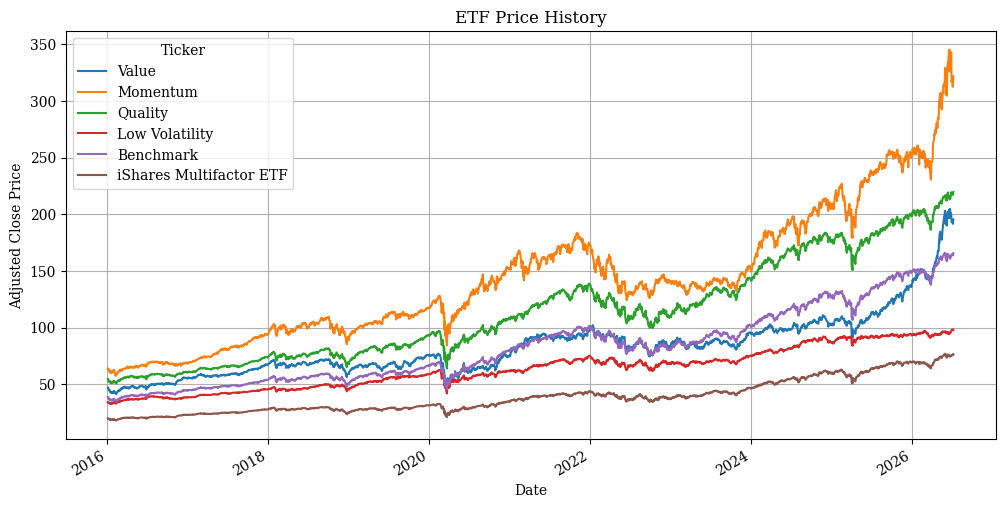

In [829]:
prices.plot(figsize=(12, 6))

plt.title("ETF Price History")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.grid(True)
plt.show()

## Returns and Cumulative Performance

This section converts ETF adjusted prices into daily returns. Returns are the core input for the rest of the project because all performance metrics, risk measures and portfolio allocations are computed from returns rather than raw prices.

The section also computes cumulative performance, which shows the growth of $1 invested in each ETF over the sample period.

In [830]:
returns = prices.pct_change().dropna()

returns.head()

Ticker,Value,Momentum,Quality,Low Volatility,Benchmark,iShares Multifactor ETF
Date,,,,,,
2016-01-05,0.001634,0.004735,0.002672,0.006779,0.001749,0.008457
2016-01-06,-0.018277,-0.005267,-0.011914,-0.006253,-0.014186,-0.015094
2016-01-07,-0.021609,-0.022294,-0.023798,-0.016215,-0.024020,-0.019583
2016-01-08,-0.010873,-0.009548,-0.011376,-0.010086,-0.011796,-0.007121
2016-01-11,-0.006183,0.006043,0.001479,0.001491,-0.000229,-0.016268


In [831]:
returns.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2643 entries, 2016-01-05 to 2026-07-10
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Value                    2643 non-null   float64
 1   Momentum                 2643 non-null   float64
 2   Quality                  2643 non-null   float64
 3   Low Volatility           2643 non-null   float64
 4   Benchmark                2643 non-null   float64
 5   iShares Multifactor ETF  2643 non-null   float64
dtypes: float64(6)
memory usage: 144.5 KB


In [832]:
returns.describe()

Ticker,Value,Momentum,Quality,Low Volatility,Benchmark,iShares Multifactor ETF
count,2643.000000,2643.000000,2643.000000,2643.000000,2643.000000,2643.000000
mean,0.000618,0.000703,0.000591,0.000439,0.000616,0.000575
std,0.012538,0.013373,0.011300,0.009047,0.011432,0.011454
min,-0.126879,-0.123652,-0.101815,-0.100817,-0.115729,-0.120482
25%,-0.004997,-0.004916,-0.003798,-0.003129,-0.003741,-0.004220
50%,0.000575,0.001320,0.000671,0.000784,0.000805,0.000899
75%,0.006989,0.007097,0.005994,0.004547,0.006185,0.006139
max,0.100307,0.106463,0.103637,0.086677,0.096097,0.098253


In [833]:
factor_returns = returns[factor_columns]

benchmark_returns = returns[benchmark_column]

multifactor_returns = returns[multifactor_column]

In [834]:
print("Factor returns columns:")
print(factor_returns.columns.tolist())

print("\nBenchmark:")
print(benchmark_column)

print("\nMultifactor comparator:")
print(multifactor_column)

Factor returns columns:
['Value', 'Momentum', 'Quality', 'Low Volatility']

Benchmark:
Benchmark

Multifactor comparator:
iShares Multifactor ETF


In [835]:
cumulative_performance = (1 + returns).cumprod()

cumulative_performance.head()

Ticker,Value,Momentum,Quality,Low Volatility,Benchmark,iShares Multifactor ETF
Date,,,,,,
2016-01-05,1.001634,1.004735,1.002672,1.006779,1.001749,1.008457
2016-01-06,0.983328,0.999444,0.990726,1.000484,0.987538,0.993235
2016-01-07,0.962079,0.977162,0.967149,0.984261,0.963817,0.973784
2016-01-08,0.951618,0.967832,0.956146,0.974334,0.952448,0.966850
2016-01-11,0.945734,0.973681,0.957561,0.975787,0.952230,0.951121


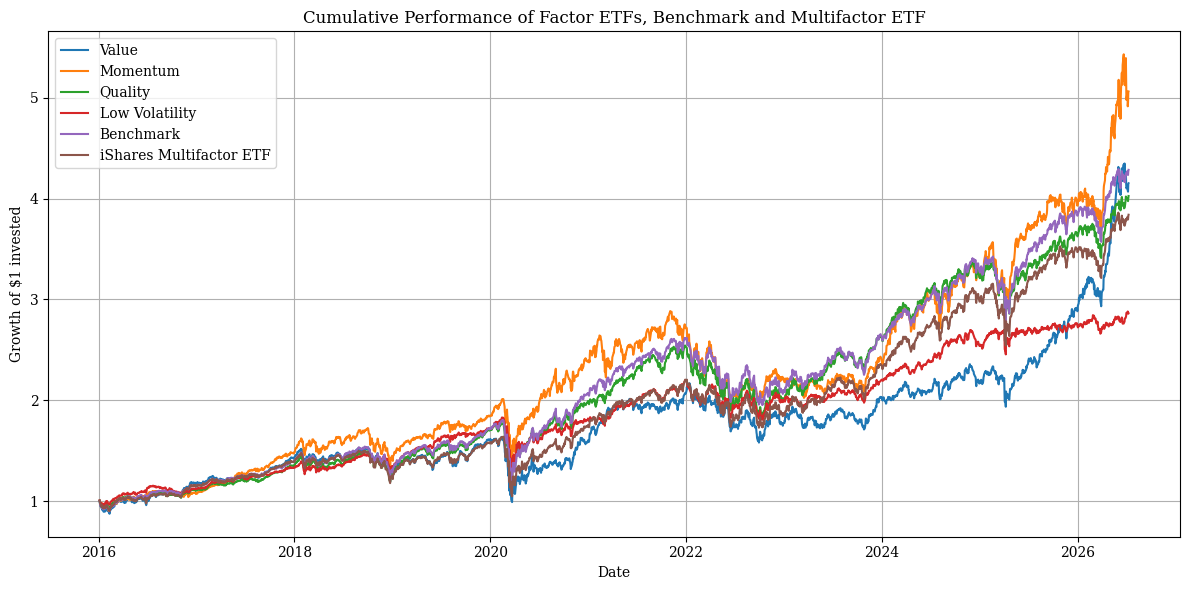

In [836]:
plt.figure(figsize=(12, 6))

for column in cumulative_performance.columns:
    plt.plot(
        cumulative_performance.index,
        cumulative_performance[column],
        label=column
    )

plt.title("Cumulative Performance of Factor ETFs, Benchmark and Multifactor ETF")
plt.xlabel("Date")
plt.ylabel("Growth of $1 invested")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The cumulative performance chart provides a first comparison of the ETF universe. It shows how the four single-factor ETFs, the broad U.S. equity benchmark and the iShares multifactor ETF evolved over the sample period.

However, cumulative performance alone is not sufficient to evaluate the attractiveness of each exposure. The next sections will complement this view with risk-adjusted metrics, rolling analysis and drawdown analysis.

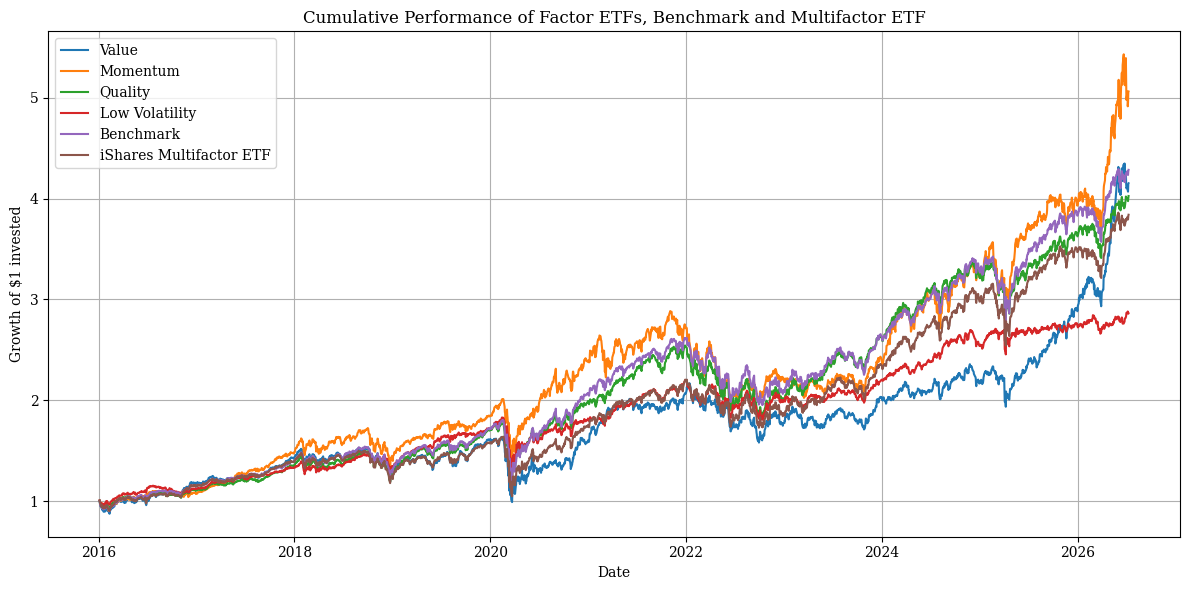

In [837]:
cumulative_chart_path = OUTPUT_DIR / "01_cumulative_performance.png"

plt.figure(figsize=(12, 6))

for column in cumulative_performance.columns:
    plt.plot(
        cumulative_performance.index,
        cumulative_performance[column],
        label=column
    )

plt.title("Cumulative Performance of Factor ETFs, Benchmark and Multifactor ETF")
plt.xlabel("Date")
plt.ylabel("Growth of $1 invested")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(cumulative_chart_path, dpi=150)
plt.show()

In [838]:
print("Chart saved to:", cumulative_chart_path)
print("File exists:", cumulative_chart_path.exists())

Chart saved to: outputs/01_cumulative_performance.png
File exists: True


## Performance Metrics

This section computes standard performance and risk metrics for each ETF in the universe.

The objective is to compare the factor ETFs, the broad U.S. equity benchmark and the iShares multifactor ETF not only in terms of total performance, but also in terms of risk-adjusted performance and downside risk.

The metrics include:
- Annualized return
- Annualized volatility
- Sharpe ratio
- Maximum drawdown
- Calmar ratio
- Correlation with the benchmark

In [839]:
def cumulative_returns(return_data):
    cumulative = (1 + return_data).cumprod()
    return cumulative

In [840]:
def annualized_return(return_series, periods_per_year=TRADING_DAYS):
    return_series = return_series.dropna()
    total_return = (1 + return_series).prod()
    number_of_years = len(return_series) / periods_per_year
    annualized = total_return ** (1 / number_of_years) - 1
    return annualized

In [841]:
def annualized_volatility(return_series, periods_per_year=TRADING_DAYS):
    return_series = return_series.dropna()
    volatility = return_series.std() * np.sqrt(periods_per_year)
    return volatility

In [842]:
def sharpe_ratio(return_series, risk_free_rate=0.0, periods_per_year=TRADING_DAYS):
    ann_return = annualized_return(return_series, periods_per_year)
    ann_volatility = annualized_volatility(return_series, periods_per_year)

    if ann_volatility == 0 or np.isnan(ann_volatility):
        return np.nan

    sharpe = (ann_return - risk_free_rate) / ann_volatility
    return sharpe

In [843]:
def drawdown_series(return_data):
    cumulative = cumulative_returns(return_data)
    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1
    return drawdown

In [844]:
def maximum_drawdown(return_series):
    drawdowns = drawdown_series(return_series)
    max_dd = drawdowns.min()
    return max_dd

In [845]:
def calmar_ratio(return_series):
    ann_return = annualized_return(return_series)
    max_dd = abs(maximum_drawdown(return_series))

    if max_dd == 0 or np.isnan(max_dd):
        return np.nan

    calmar = ann_return / max_dd
    return calmar

In [846]:
def performance_summary(return_data, benchmark_series=None):
    summary = pd.DataFrame(index=return_data.columns)

    summary["Annualized Return"] = return_data.apply(annualized_return)
    summary["Annualized Volatility"] = return_data.apply(annualized_volatility)
    summary["Sharpe Ratio"] = return_data.apply(sharpe_ratio)
    summary["Maximum Drawdown"] = return_data.apply(maximum_drawdown)
    summary["Calmar Ratio"] = return_data.apply(calmar_ratio)

    if benchmark_series is not None:
        summary["Correlation vs Benchmark"] = return_data.apply(
            lambda x: x.corr(benchmark_series.loc[x.index])
        )

    return summary

In [847]:
etf_performance_summary = performance_summary(
    returns,
    benchmark_series=benchmark_returns
)

etf_performance_summary

,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown,Calmar Ratio,Correlation vs Benchmark
Ticker,,,,,,
Value,0.145383,0.199042,0.730413,-0.394705,0.368333,0.908321
Momentum,0.167225,0.212297,0.787695,-0.340823,0.490651,0.884324
Quality,0.142011,0.179383,0.791667,-0.340567,0.416985,0.980021
Low Volatility,0.105502,0.143620,0.734587,-0.330989,0.318746,0.884003
Benchmark,0.148829,0.181474,0.820110,-0.350039,0.425178,1.000000
iShares Multifactor ETF,0.136880,0.181831,0.752789,-0.360335,0.379869,0.980008


In [848]:
def format_performance_table(summary_table):
    formatted = summary_table.copy()

    percent_columns = [
        "Annualized Return",
        "Annualized Volatility",
        "Maximum Drawdown",
        "Correlation vs Benchmark"
    ]

    for column in percent_columns:
        if column in formatted.columns:
            formatted[column] = formatted[column].map(
                lambda x: f"{x:.2%}" if pd.notna(x) else ""
            )

    for column in ["Sharpe Ratio", "Calmar Ratio"]:
        if column in formatted.columns:
            formatted[column] = formatted[column].map(
                lambda x: f"{x:.2f}" if pd.notna(x) else ""
            )

    return formatted

In [849]:
etf_performance_summary_formatted = format_performance_table(
    etf_performance_summary
)

etf_performance_summary_formatted

,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown,Calmar Ratio,Correlation vs Benchmark
Ticker,,,,,,
Value,14.54%,19.90%,0.73,-39.47%,0.37,90.83%
Momentum,16.72%,21.23%,0.79,-34.08%,0.49,88.43%
Quality,14.20%,17.94%,0.79,-34.06%,0.42,98.00%
Low Volatility,10.55%,14.36%,0.73,-33.10%,0.32,88.40%
Benchmark,14.88%,18.15%,0.82,-35.00%,0.43,100.00%
iShares Multifactor ETF,13.69%,18.18%,0.75,-36.03%,0.38,98.00%


In [850]:
performance_table_path = OUTPUT_DIR / "02_etf_performance_summary.csv"

etf_performance_summary.to_csv(performance_table_path)

print("Performance table saved to:", performance_table_path)
print("File exists:", performance_table_path.exists())

Performance table saved to: outputs/02_etf_performance_summary.csv
File exists: True


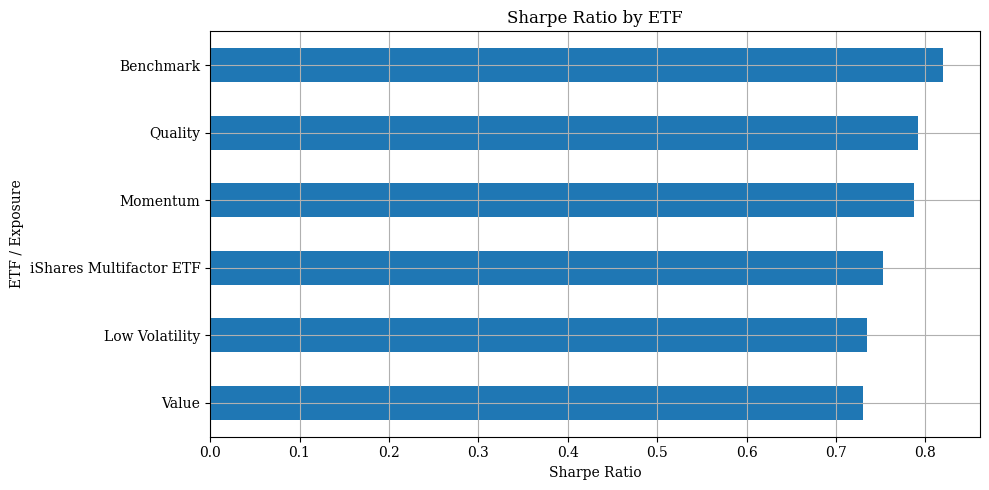

In [851]:
plt.figure(figsize=(10, 5))

etf_performance_summary["Sharpe Ratio"].sort_values().plot(kind="barh")

plt.title("Sharpe Ratio by ETF")
plt.xlabel("Sharpe Ratio")
plt.ylabel("ETF / Exposure")
plt.grid(True)
plt.tight_layout()
plt.show()

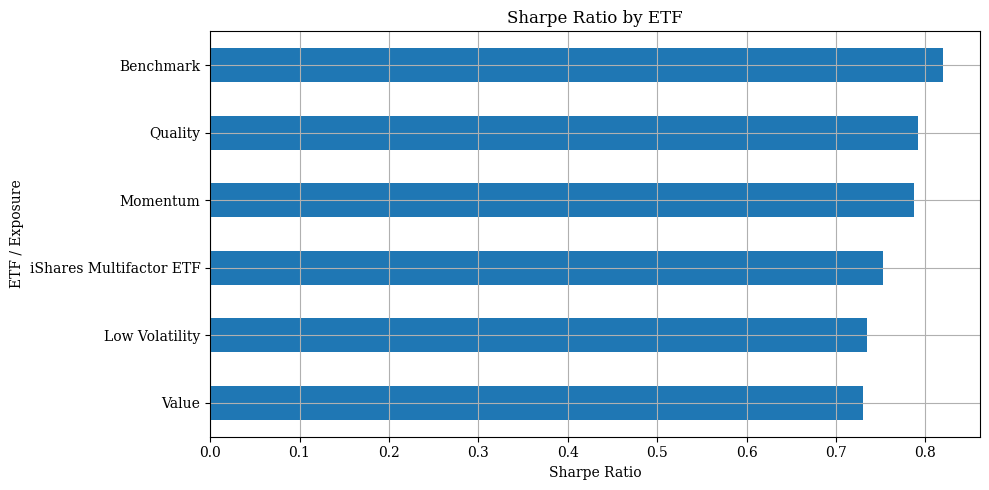

Chart saved to: outputs/03_sharpe_ratio_by_etf.png
File exists: True


In [852]:
sharpe_chart_path = OUTPUT_DIR / "03_sharpe_ratio_by_etf.png"

plt.figure(figsize=(10, 5))

etf_performance_summary["Sharpe Ratio"].sort_values().plot(kind="barh")

plt.title("Sharpe Ratio by ETF")
plt.xlabel("Sharpe Ratio")
plt.ylabel("ETF / Exposure")
plt.grid(True)
plt.tight_layout()
plt.savefig(sharpe_chart_path, dpi=150)
plt.show()

print("Chart saved to:", sharpe_chart_path)
print("File exists:", sharpe_chart_path.exists())

The performance metrics provide a more complete view than cumulative returns alone. Annualized return measures long-term performance, while annualized volatility and maximum drawdown capture risk. The Sharpe ratio and Calmar ratio help compare performance relative to risk. Correlation with the benchmark indicates whether each ETF behaves similarly to the broad U.S. equity market or provides a more differentiated exposure.

## Rolling Metrics and Factor Cyclicality

This section studies factor cyclicality using rolling 12-month metrics. Instead of looking only at full-period performance, rolling metrics show how each factor behaves through time.

This is important because factor performance is not stable. Value, Momentum, Quality and Low Volatility may outperform or underperform the benchmark during different market regimes.

The analysis focuses on:
- Rolling 12-month returns
- Rolling excess returns versus the benchmark
- Rolling annualized volatility
- Rolling Sharpe ratios

In [853]:
def rolling_compound_return(return_data, window=ROLLING_WINDOW):
    rolling_return = return_data.rolling(window).apply(
        lambda x: np.prod(1 + x) - 1,
        raw=True
    )
    return rolling_return

In [854]:
def rolling_annualized_volatility(return_data, window=ROLLING_WINDOW):
    rolling_volatility = return_data.rolling(window).std() * np.sqrt(TRADING_DAYS)
    return rolling_volatility

In [855]:
def rolling_sharpe_ratio(return_data, window=ROLLING_WINDOW):
    rolling_annualized_return = return_data.rolling(window).mean() * TRADING_DAYS
    rolling_volatility = rolling_annualized_volatility(return_data, window)
    rolling_sharpe = rolling_annualized_return / rolling_volatility
    return rolling_sharpe

In [856]:
rolling_returns = rolling_compound_return(returns, ROLLING_WINDOW)

rolling_volatility = rolling_annualized_volatility(returns, ROLLING_WINDOW)

rolling_sharpe = rolling_sharpe_ratio(returns, ROLLING_WINDOW)

In [857]:
rolling_returns.tail()

Ticker,Value,Momentum,Quality,Low Volatility,Benchmark,iShares Multifactor ETF
Date,,,,,,
2026-07-06,0.717033,0.367649,0.199091,0.064390,0.229136,0.193966
2026-07-07,0.689089,0.314535,0.188321,0.060533,0.212757,0.178901
2026-07-08,0.705808,0.329116,0.192679,0.056575,0.217831,0.183385
2026-07-09,0.725271,0.368195,0.199994,0.059308,0.228706,0.196322
2026-07-10,0.725563,0.362211,0.199157,0.059007,0.225115,0.193494


In [858]:
rolling_excess_returns = rolling_returns[factor_columns].subtract(
    rolling_returns[benchmark_column],
    axis=0
)

rolling_excess_returns.tail()

Ticker,Value,Momentum,Quality,Low Volatility
Date,,,,
2026-07-06,0.487897,0.138513,-0.030046,-0.164747
2026-07-07,0.476331,0.101777,-0.024437,-0.152225
2026-07-08,0.487977,0.111285,-0.025152,-0.161256
2026-07-09,0.496565,0.139489,-0.028712,-0.169398
2026-07-10,0.500447,0.137096,-0.025958,-0.166108


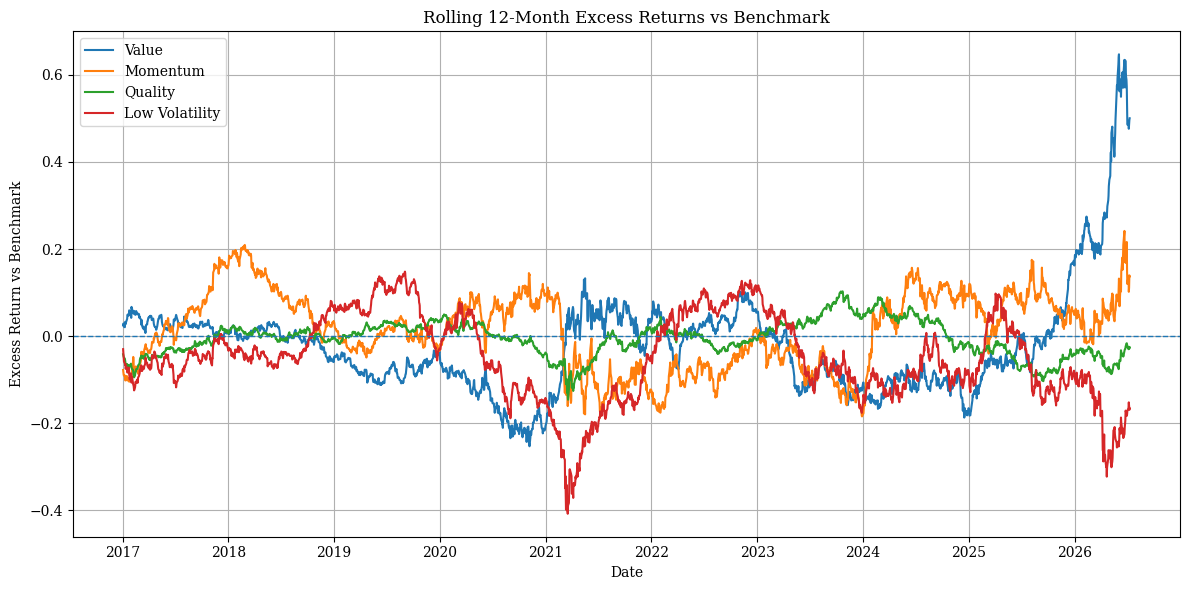

In [859]:
plt.figure(figsize=(12, 6))

for column in rolling_excess_returns.columns:
    plt.plot(
        rolling_excess_returns.index,
        rolling_excess_returns[column],
        label=column
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Rolling 12-Month Excess Returns vs Benchmark")
plt.xlabel("Date")
plt.ylabel("Excess Return vs Benchmark")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

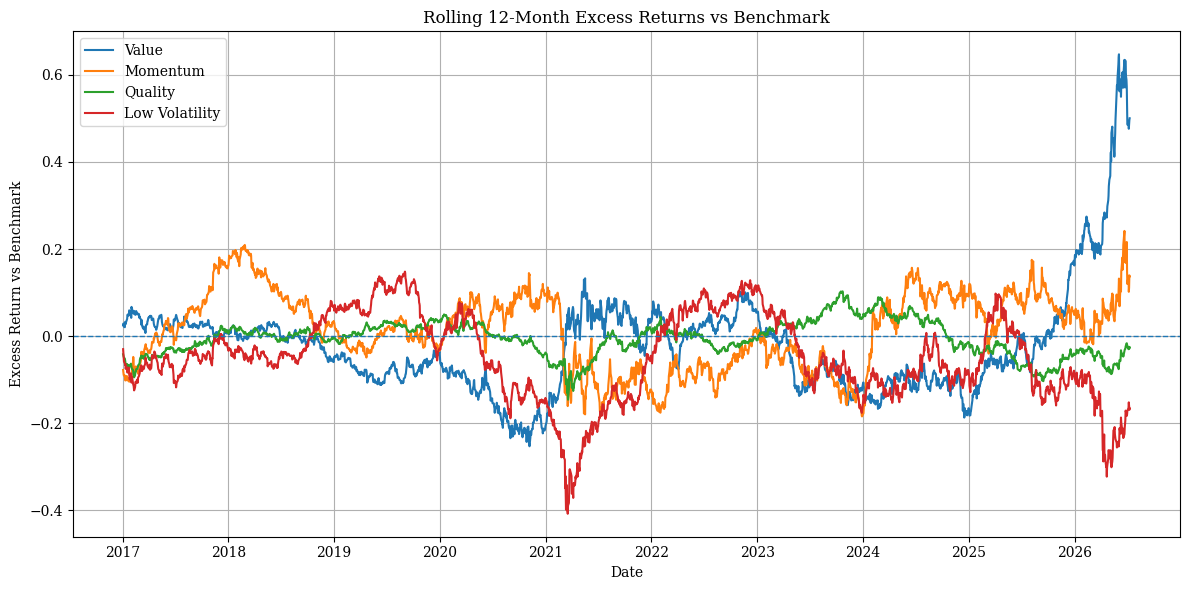

Chart saved to: outputs/04_rolling_excess_returns.png
File exists: True


In [860]:
rolling_excess_chart_path = OUTPUT_DIR / "04_rolling_excess_returns.png"

plt.figure(figsize=(12, 6))

for column in rolling_excess_returns.columns:
    plt.plot(
        rolling_excess_returns.index,
        rolling_excess_returns[column],
        label=column
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Rolling 12-Month Excess Returns vs Benchmark")
plt.xlabel("Date")
plt.ylabel("Excess Return vs Benchmark")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(rolling_excess_chart_path, dpi=150)
plt.show()

print("Chart saved to:", rolling_excess_chart_path)
print("File exists:", rolling_excess_chart_path.exists())

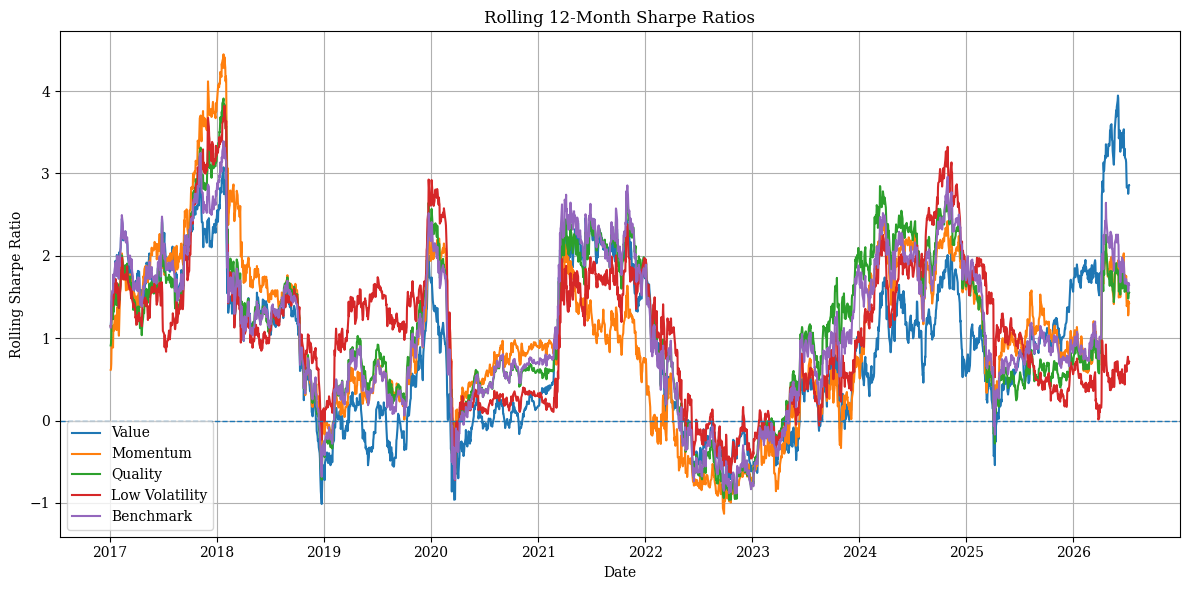

In [861]:
plt.figure(figsize=(12, 6))

for column in factor_columns + [benchmark_column]:
    plt.plot(
        rolling_sharpe.index,
        rolling_sharpe[column],
        label=column
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Rolling 12-Month Sharpe Ratios")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

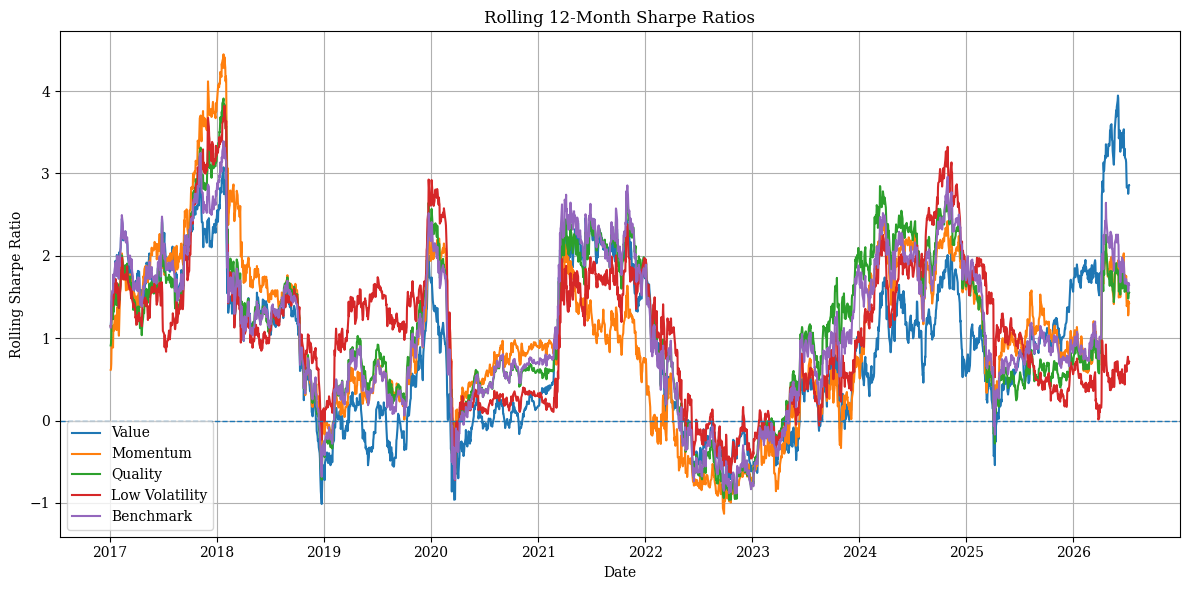

Chart saved to: outputs/05_rolling_sharpe_ratios.png
File exists: True


In [862]:
rolling_sharpe_chart_path = OUTPUT_DIR / "05_rolling_sharpe_ratios.png"

plt.figure(figsize=(12, 6))

for column in factor_columns + [benchmark_column]:
    plt.plot(
        rolling_sharpe.index,
        rolling_sharpe[column],
        label=column
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Rolling 12-Month Sharpe Ratios")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(rolling_sharpe_chart_path, dpi=150)
plt.show()

print("Chart saved to:", rolling_sharpe_chart_path)
print("File exists:", rolling_sharpe_chart_path.exists())

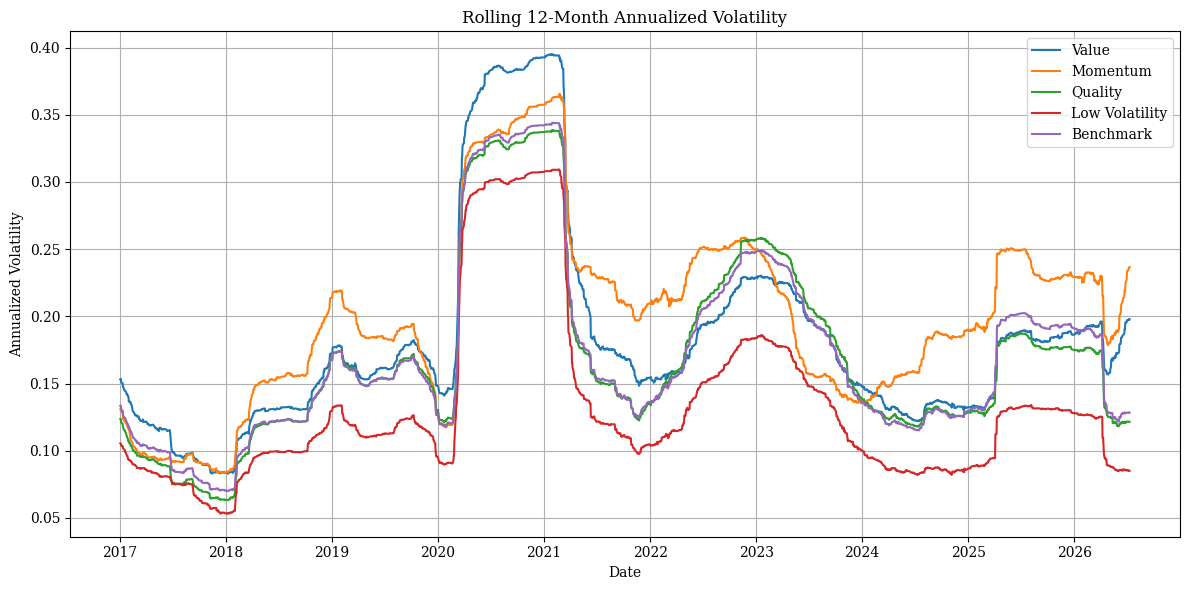

In [863]:
plt.figure(figsize=(12, 6))

for column in factor_columns + [benchmark_column]:
    plt.plot(
        rolling_volatility.index,
        rolling_volatility[column],
        label=column
    )

plt.title("Rolling 12-Month Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

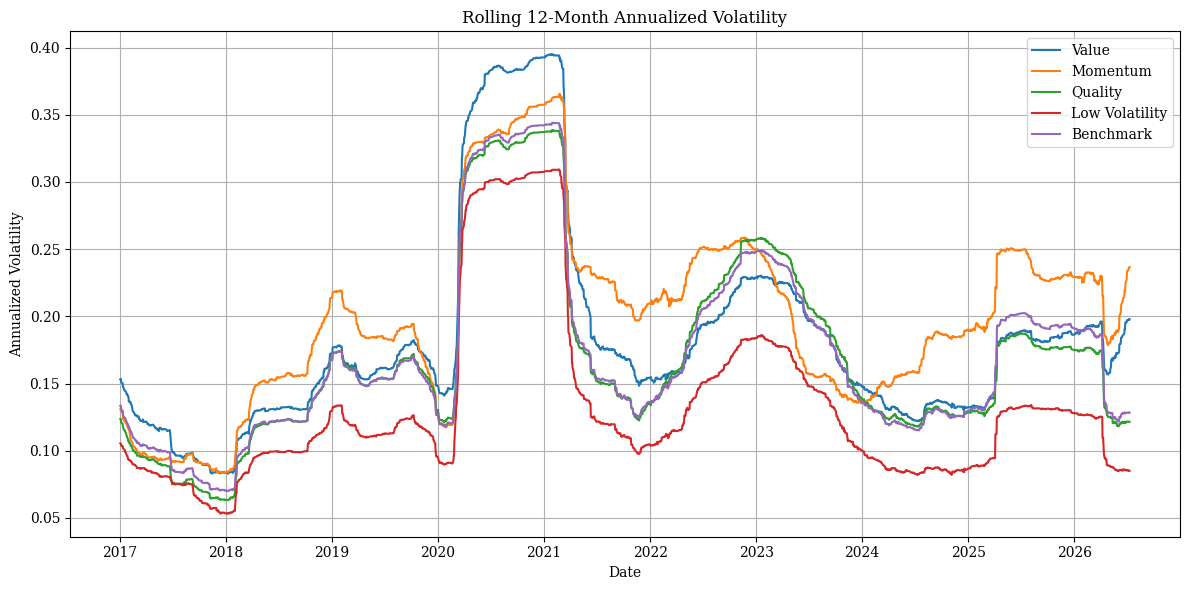

Chart saved to: outputs/06_rolling_volatility.png
File exists: True


In [864]:
rolling_volatility_chart_path = OUTPUT_DIR / "06_rolling_volatility.png"

plt.figure(figsize=(12, 6))

for column in factor_columns + [benchmark_column]:
    plt.plot(
        rolling_volatility.index,
        rolling_volatility[column],
        label=column
    )

plt.title("Rolling 12-Month Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(rolling_volatility_chart_path, dpi=150)
plt.show()

print("Chart saved to:", rolling_volatility_chart_path)
print("File exists:", rolling_volatility_chart_path.exists())

In [865]:
latest_rolling_metrics = pd.DataFrame({
    "Latest Rolling 12M Return": rolling_returns.iloc[-1],
    "Latest Rolling 12M Volatility": rolling_volatility.iloc[-1],
    "Latest Rolling 12M Sharpe": rolling_sharpe.iloc[-1]
})

latest_rolling_metrics

,Latest Rolling 12M Return,Latest Rolling 12M Volatility,Latest Rolling 12M Sharpe
Ticker,,,
Value,0.725563,0.197834,2.858848
Momentum,0.362211,0.236557,1.425660
Quality,0.199157,0.121520,1.555569
Low Volatility,0.059007,0.085078,0.716328
Benchmark,0.225115,0.128288,1.647217
iShares Multifactor ETF,0.193494,0.125814,1.469110


In [866]:
latest_rolling_metrics_formatted = latest_rolling_metrics.copy()

latest_rolling_metrics_formatted["Latest Rolling 12M Return"] = latest_rolling_metrics_formatted["Latest Rolling 12M Return"].map(
    lambda x: f"{x:.2%}" if pd.notna(x) else ""
)

latest_rolling_metrics_formatted["Latest Rolling 12M Volatility"] = latest_rolling_metrics_formatted["Latest Rolling 12M Volatility"].map(
    lambda x: f"{x:.2%}" if pd.notna(x) else ""
)

latest_rolling_metrics_formatted["Latest Rolling 12M Sharpe"] = latest_rolling_metrics_formatted["Latest Rolling 12M Sharpe"].map(
    lambda x: f"{x:.2f}" if pd.notna(x) else ""
)

latest_rolling_metrics_formatted

,Latest Rolling 12M Return,Latest Rolling 12M Volatility,Latest Rolling 12M Sharpe
Ticker,,,
Value,72.56%,19.78%,2.86
Momentum,36.22%,23.66%,1.43
Quality,19.92%,12.15%,1.56
Low Volatility,5.90%,8.51%,0.72
Benchmark,22.51%,12.83%,1.65
iShares Multifactor ETF,19.35%,12.58%,1.47


In [867]:
latest_rolling_metrics_path = OUTPUT_DIR / "07_latest_rolling_metrics.csv"

latest_rolling_metrics.to_csv(latest_rolling_metrics_path)

print("Latest rolling metrics saved to:", latest_rolling_metrics_path)
print("File exists:", latest_rolling_metrics_path.exists())

Latest rolling metrics saved to: outputs/07_latest_rolling_metrics.csv
File exists: True


The rolling metrics highlight the cyclicality of factor performance. The rolling excess return chart shows that factor ETFs do not outperform the benchmark consistently. Each factor experiences periods of relative strength and weakness.

This supports the idea that factor allocation is dynamic by nature. However, the presence of factor cyclicality does not mean that factor timing is easy. The following sections will therefore use simple and transparent allocation rules rather than a complex predictive model.

## Drawdown Analysis

This section analyzes downside risk through drawdowns. A drawdown measures the decline of an investment from its previous peak.

This is important because two ETFs can have similar long-term returns but very different downside risk. Maximum drawdown helps evaluate the worst peak-to-trough loss experienced over the sample period.

The objective is to complement return and Sharpe ratio analysis with a clearer view of downside risk.

In [868]:
drawdowns = drawdown_series(returns)

drawdowns.head()

Ticker,Value,Momentum,Quality,Low Volatility,Benchmark,iShares Multifactor ETF
Date,,,,,,
2016-01-05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2016-01-06,-0.018277,-0.005267,-0.011914,-0.006253,-0.014186,-0.015094
2016-01-07,-0.039491,-0.027443,-0.035429,-0.022366,-0.037865,-0.034382
2016-01-08,-0.049935,-0.036729,-0.046402,-0.032227,-0.049214,-0.041258
2016-01-11,-0.055809,-0.030908,-0.044991,-0.030784,-0.049433,-0.056855


In [869]:
drawdowns.tail()

Ticker,Value,Momentum,Quality,Low Volatility,Benchmark,iShares Multifactor ETF
Date,,,,,,
2026-07-06,-0.051762,-0.068102,-0.004284,0.000000,-0.004655,-0.011092
2026-07-07,-0.062173,-0.094954,-0.007702,0.000000,-0.010323,-0.015385
2026-07-08,-0.064177,-0.087973,-0.011439,-0.007117,-0.013519,-0.017727
2026-07-09,-0.046385,-0.069579,-0.004238,-0.007626,-0.005077,-0.009141
2026-07-10,-0.045066,-0.067928,0.000000,-0.005999,-0.001700,-0.005499


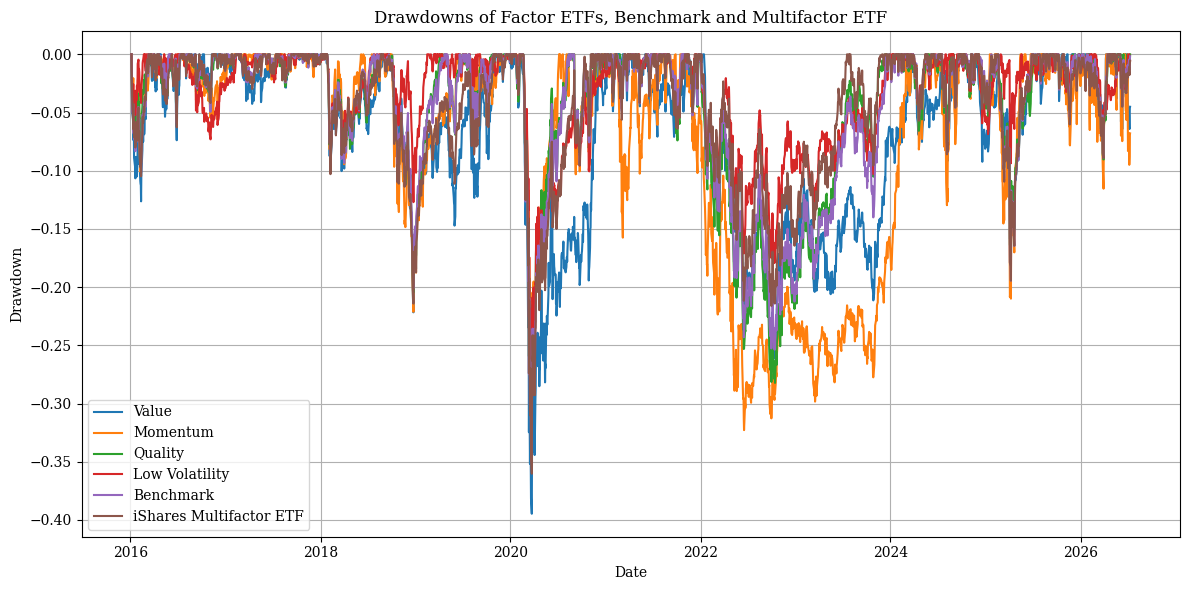

In [870]:
plt.figure(figsize=(12, 6))

for column in drawdowns.columns:
    plt.plot(
        drawdowns.index,
        drawdowns[column],
        label=column
    )

plt.title("Drawdowns of Factor ETFs, Benchmark and Multifactor ETF")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

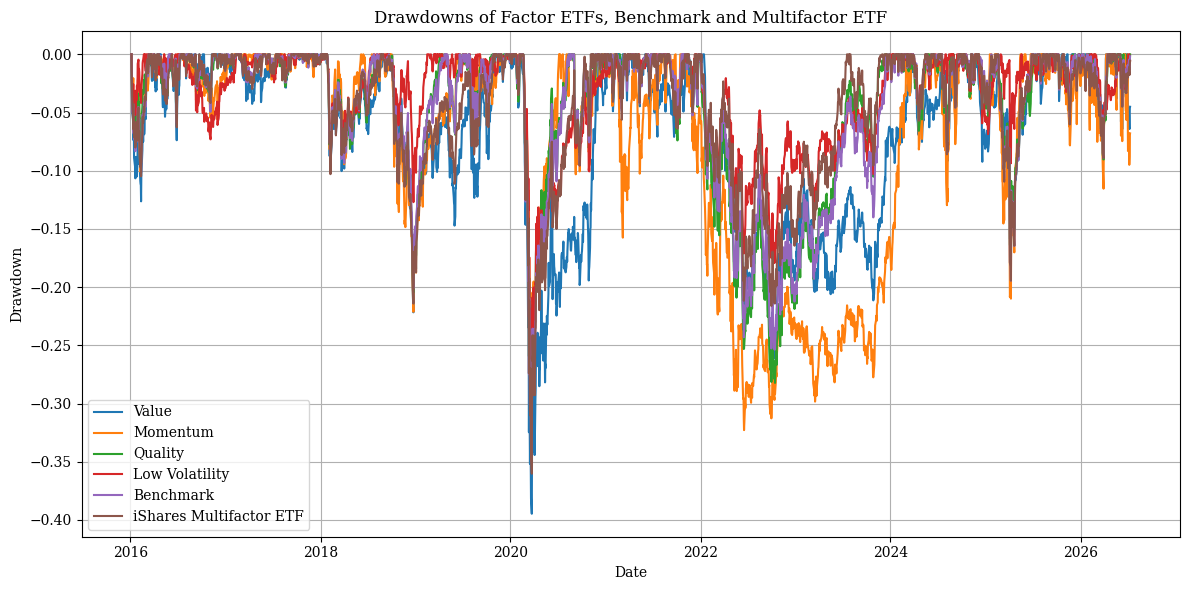

Chart saved to: outputs/08_drawdowns.png
File exists: True


In [871]:
drawdown_chart_path = OUTPUT_DIR / "08_drawdowns.png"

plt.figure(figsize=(12, 6))

for column in drawdowns.columns:
    plt.plot(
        drawdowns.index,
        drawdowns[column],
        label=column
    )

plt.title("Drawdowns of Factor ETFs, Benchmark and Multifactor ETF")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(drawdown_chart_path, dpi=150)
plt.show()

print("Chart saved to:", drawdown_chart_path)
print("File exists:", drawdown_chart_path.exists())

In [872]:
maximum_drawdowns = drawdowns.min()

maximum_drawdowns

,0
Ticker,
Value,-0.394705
Momentum,-0.340823
Quality,-0.340567
Low Volatility,-0.330989
Benchmark,-0.350039
iShares Multifactor ETF,-0.360335


In [873]:
drawdown_summary = pd.DataFrame({
    "Maximum Drawdown": maximum_drawdowns,
    "Date of Maximum Drawdown": drawdowns.idxmin()
})

drawdown_summary = drawdown_summary.sort_values("Maximum Drawdown")

drawdown_summary

,Maximum Drawdown,Date of Maximum Drawdown
Ticker,,
Value,-0.394705,2020-03-23
iShares Multifactor ETF,-0.360335,2020-03-23
Benchmark,-0.350039,2020-03-23
Momentum,-0.340823,2020-03-23
Quality,-0.340567,2020-03-23
Low Volatility,-0.330989,2020-03-23


In [874]:
drawdown_summary_formatted = drawdown_summary.copy()

drawdown_summary_formatted["Maximum Drawdown"] = drawdown_summary_formatted["Maximum Drawdown"].map(
    lambda x: f"{x:.2%}" if pd.notna(x) else ""
)

drawdown_summary_formatted

,Maximum Drawdown,Date of Maximum Drawdown
Ticker,,
Value,-39.47%,2020-03-23
iShares Multifactor ETF,-36.03%,2020-03-23
Benchmark,-35.00%,2020-03-23
Momentum,-34.08%,2020-03-23
Quality,-34.06%,2020-03-23
Low Volatility,-33.10%,2020-03-23


In [875]:
drawdown_summary_path = OUTPUT_DIR / "09_drawdown_summary.csv"

drawdown_summary.to_csv(drawdown_summary_path)

print("Drawdown summary saved to:", drawdown_summary_path)
print("File exists:", drawdown_summary_path.exists())

Drawdown summary saved to: outputs/09_drawdown_summary.csv
File exists: True


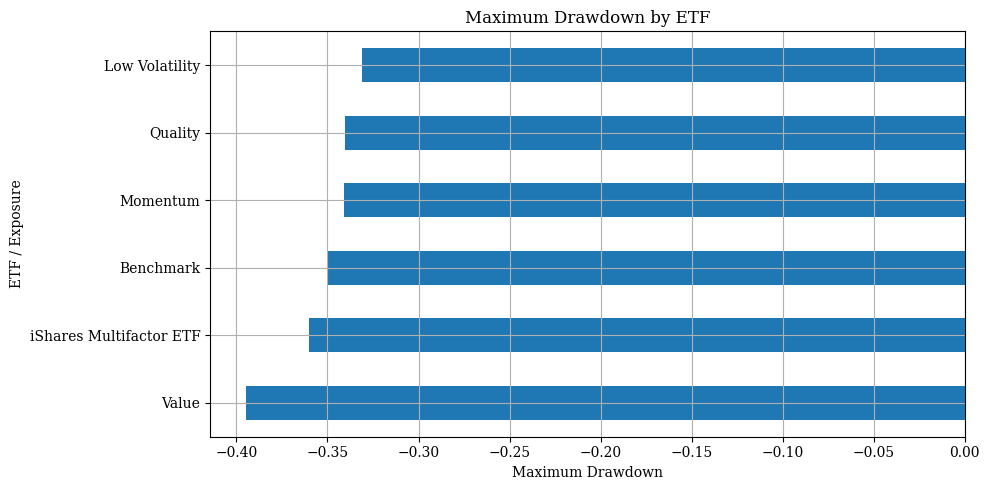

In [876]:
plt.figure(figsize=(10, 5))

drawdown_summary["Maximum Drawdown"].sort_values().plot(kind="barh")

plt.title("Maximum Drawdown by ETF")
plt.xlabel("Maximum Drawdown")
plt.ylabel("ETF / Exposure")
plt.grid(True)
plt.tight_layout()
plt.show()

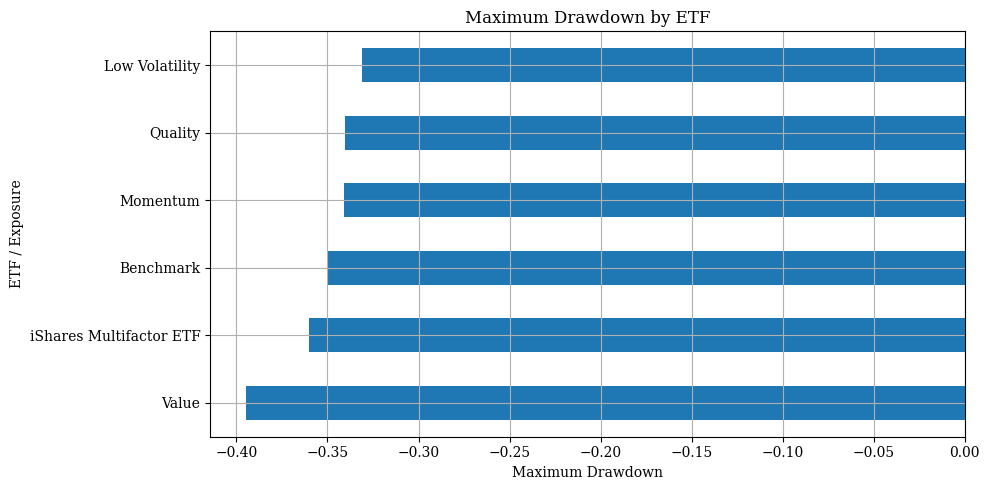

Chart saved to: outputs/10_maximum_drawdown_by_etf.png
File exists: True


In [877]:
max_drawdown_chart_path = OUTPUT_DIR / "10_maximum_drawdown_by_etf.png"

plt.figure(figsize=(10, 5))

drawdown_summary["Maximum Drawdown"].sort_values().plot(kind="barh")

plt.title("Maximum Drawdown by ETF")
plt.xlabel("Maximum Drawdown")
plt.ylabel("ETF / Exposure")
plt.grid(True)
plt.tight_layout()
plt.savefig(max_drawdown_chart_path, dpi=150)
plt.show()

print("Chart saved to:", max_drawdown_chart_path)
print("File exists:", max_drawdown_chart_path.exists())

The drawdown analysis shows the downside risk experienced by each ETF over the sample period. Maximum drawdown is particularly important because it captures the worst peak-to-trough decline an investor would have faced.

This complements the Sharpe ratio analysis. An ETF may deliver attractive long-term returns, but still expose investors to severe temporary losses. Drawdown analysis therefore helps evaluate the risk profile of each factor exposure more realistically.

## Equal-Weight Factor Portfolio

This section builds a simple static factor portfolio using the four single-factor ETFs: Value, Momentum, Quality and Low Volatility.

Each factor receives an equal weight of 25%. This portfolio serves as a simple benchmark for factor diversification before introducing a dynamic allocation framework.

The objective is to test whether combining factor ETFs in a diversified way provides a different risk-return profile compared with the broad U.S. equity benchmark and the iShares multifactor ETF.

In [878]:
equal_weight_weights = pd.Series(
    1 / len(factor_columns),
    index=factor_columns
)

equal_weight_weights

,0
Value,0.25
Momentum,0.25
Quality,0.25
Low Volatility,0.25


In [879]:
equal_weight_factor_returns = factor_returns.dot(equal_weight_weights)

equal_weight_factor_returns.name = "Equal-Weight Factor Portfolio"

equal_weight_factor_returns.head()

,Equal-Weight Factor Portfolio
Date,
2016-01-05,0.003955
2016-01-06,-0.010428
2016-01-07,-0.020979
2016-01-08,-0.010471
2016-01-11,0.000708


In [880]:
equal_weight_cumulative_performance = cumulative_returns(equal_weight_factor_returns)

equal_weight_cumulative_performance.head()

,Equal-Weight Factor Portfolio
Date,
2016-01-05,1.003955
2016-01-06,0.993486
2016-01-07,0.972644
2016-01-08,0.962459
2016-01-11,0.963141


In [881]:
static_comparison_returns = pd.concat(
    [
        benchmark_returns.rename("Benchmark ITOT"),
        multifactor_returns.rename("iShares Multifactor ETF LRGF"),
        equal_weight_factor_returns
    ],
    axis=1
).dropna()

static_comparison_returns.head()

,Benchmark ITOT,iShares Multifactor ETF LRGF,Equal-Weight Factor Portfolio
Date,,,
2016-01-05,0.001749,0.008457,0.003955
2016-01-06,-0.014186,-0.015094,-0.010428
2016-01-07,-0.024020,-0.019583,-0.020979
2016-01-08,-0.011796,-0.007121,-0.010471
2016-01-11,-0.000229,-0.016268,0.000708


In [882]:
static_comparison_summary = performance_summary(
    static_comparison_returns,
    benchmark_series=static_comparison_returns["Benchmark ITOT"]
)

static_comparison_summary_formatted = format_performance_table(static_comparison_summary)

static_comparison_summary_formatted

,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown,Calmar Ratio,Correlation vs Benchmark
Benchmark ITOT,14.88%,18.15%,0.82,-35.00%,0.43,100.00%
iShares Multifactor ETF LRGF,13.69%,18.18%,0.75,-36.03%,0.38,98.00%
Equal-Weight Factor Portfolio,14.26%,17.15%,0.83,-34.98%,0.41,97.85%


In [883]:
static_comparison_summary_path = OUTPUT_DIR / "11_static_comparison_summary.csv"

static_comparison_summary.to_csv(static_comparison_summary_path)

print("Static comparison summary saved to:", static_comparison_summary_path)
print("File exists:", static_comparison_summary_path.exists())

Static comparison summary saved to: outputs/11_static_comparison_summary.csv
File exists: True


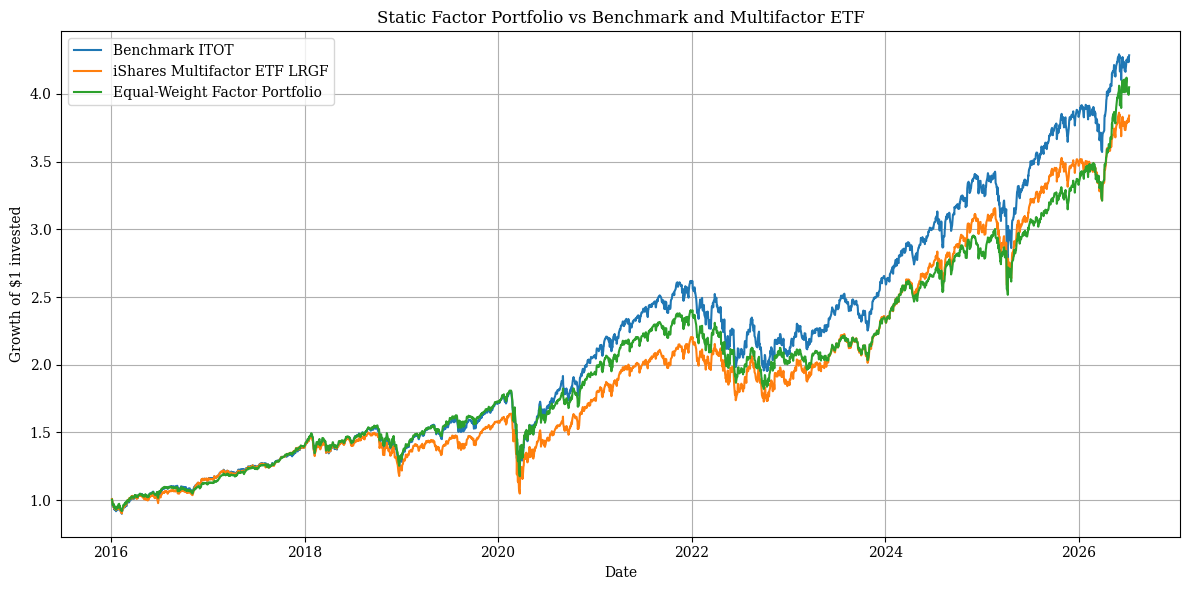

In [884]:
static_cumulative_performance = cumulative_returns(static_comparison_returns)

plt.figure(figsize=(12, 6))

for column in static_cumulative_performance.columns:
    plt.plot(
        static_cumulative_performance.index,
        static_cumulative_performance[column],
        label=column
    )

plt.title("Static Factor Portfolio vs Benchmark and Multifactor ETF")
plt.xlabel("Date")
plt.ylabel("Growth of $1 invested")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

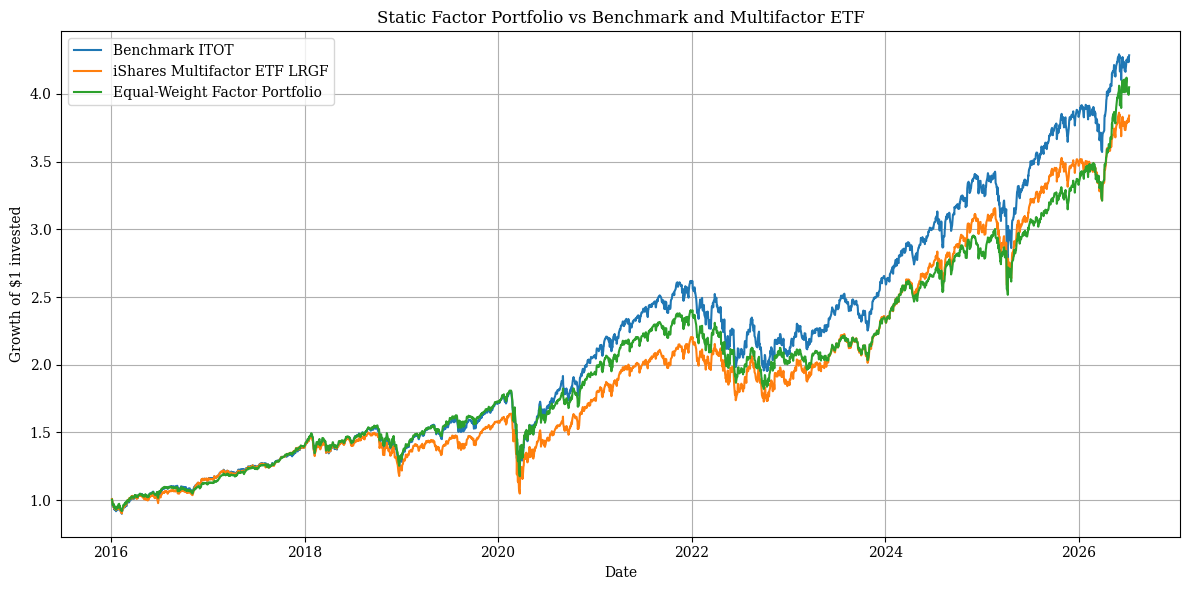

Chart saved to: outputs/12_static_factor_portfolio_comparison.png
File exists: True


In [885]:
static_comparison_chart_path = OUTPUT_DIR / "12_static_factor_portfolio_comparison.png"

static_cumulative_performance = cumulative_returns(static_comparison_returns)

plt.figure(figsize=(12, 6))

for column in static_cumulative_performance.columns:
    plt.plot(
        static_cumulative_performance.index,
        static_cumulative_performance[column],
        label=column
    )

plt.title("Static Factor Portfolio vs Benchmark and Multifactor ETF")
plt.xlabel("Date")
plt.ylabel("Growth of $1 invested")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(static_comparison_chart_path, dpi=150)
plt.show()

print("Chart saved to:", static_comparison_chart_path)
print("File exists:", static_comparison_chart_path.exists())

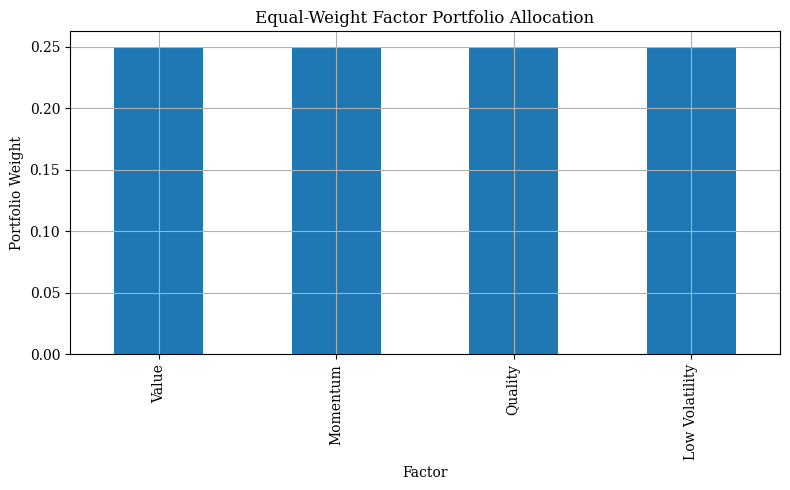

In [886]:
plt.figure(figsize=(8, 5))

equal_weight_weights.plot(kind="bar")

plt.title("Equal-Weight Factor Portfolio Allocation")
plt.xlabel("Factor")
plt.ylabel("Portfolio Weight")
plt.grid(True)
plt.tight_layout()
plt.show()

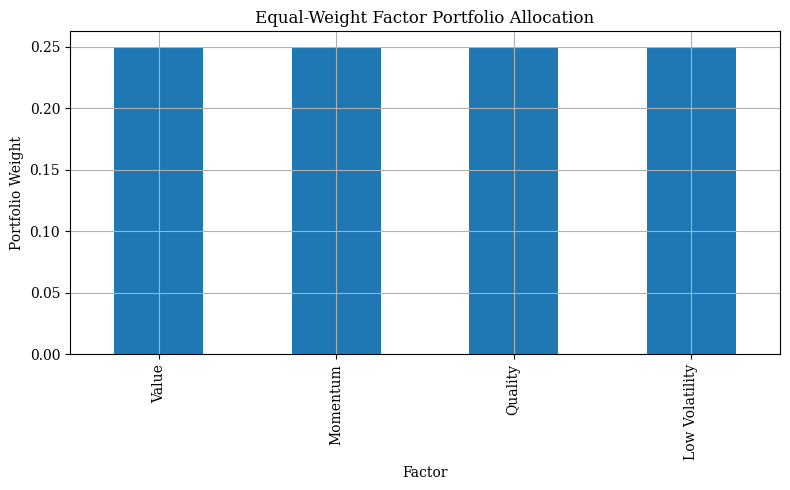

Chart saved to: outputs/13_equal_weight_allocation.png
File exists: True


In [887]:
equal_weight_allocation_chart_path = OUTPUT_DIR / "13_equal_weight_allocation.png"

plt.figure(figsize=(8, 5))

equal_weight_weights.plot(kind="bar")

plt.title("Equal-Weight Factor Portfolio Allocation")
plt.xlabel("Factor")
plt.ylabel("Portfolio Weight")
plt.grid(True)
plt.tight_layout()
plt.savefig(equal_weight_allocation_chart_path, dpi=150)
plt.show()

print("Chart saved to:", equal_weight_allocation_chart_path)
print("File exists:", equal_weight_allocation_chart_path.exists())

The equal-weight factor portfolio provides a simple static allocation across the four factor ETFs. It does not attempt to time factor cycles. Instead, it assumes that diversification across Value, Momentum, Quality and Low Volatility can provide a balanced factor exposure.

This portfolio is useful as a baseline. It allows the analysis to compare a simple diversified factor allocation with the broad U.S. equity benchmark and with an existing iShares multifactor ETF. The next step is to test whether a transparent benchmark-relative active factor selection rule can improve the risk-return profile.

## Active Factor Selection Portfolio

This section builds a simple benchmark-relative active factor selection portfolio.

The objective is not to predict markets, but to test whether a transparent dynamic allocation rule can improve the risk-return profile compared with a static equal-weight factor portfolio.

The active score is based on four benchmark-relative criteria:

- Information Ratio
- Sharpe advantage
- Volatility advantage
- Drawdown advantage

The score deliberately avoids using relative momentum directly, because Momentum is already one of the factor ETFs in the universe. This helps avoid giving an excessive structural advantage to the Momentum ETF.

The portfolio is rebalanced monthly. At each rebalancing date, only factors with positive active characteristics are selected. If no factor qualifies, the portfolio falls back to the broad U.S. equity benchmark.

In [888]:
active_weight_columns = factor_columns + [benchmark_column]

active_weight_columns

['Value', 'Momentum', 'Quality', 'Low Volatility', 'Benchmark']

In [889]:
excess_daily_returns = factor_returns.subtract(
    benchmark_returns,
    axis=0
)

excess_daily_returns.head()

Ticker,Value,Momentum,Quality,Low Volatility
Date,,,,
2016-01-05,-0.000114,0.002986,0.000923,0.005030
2016-01-06,-0.004091,0.008919,0.002272,0.007933
2016-01-07,0.002411,0.001726,0.000222,0.007805
2016-01-08,0.000922,0.002248,0.000419,0.001709
2016-01-11,-0.005954,0.006273,0.001709,0.001721


In [890]:
rolling_active_return = excess_daily_returns.rolling(ROLLING_WINDOW).mean() * TRADING_DAYS

rolling_active_return.tail()

Ticker,Value,Momentum,Quality,Low Volatility
Date,,,,
2026-07-06,0.345885,0.126089,-0.025623,-0.148586
2026-07-07,0.342952,0.100276,-0.021226,-0.138811
2026-07-08,0.348579,0.107179,-0.021739,-0.146682
2026-07-09,0.351149,0.127391,-0.024525,-0.153030
2026-07-10,0.354259,0.125931,-0.022285,-0.150374


In [891]:
rolling_tracking_error = excess_daily_returns.rolling(ROLLING_WINDOW).std() * np.sqrt(TRADING_DAYS)

rolling_tracking_error.tail()

Ticker,Value,Momentum,Quality,Low Volatility
Date,,,,
2026-07-06,0.129204,0.153491,0.039732,0.108868
2026-07-07,0.129322,0.155280,0.039749,0.109414
2026-07-08,0.129187,0.155596,0.039752,0.109370
2026-07-09,0.129342,0.155731,0.039737,0.109679
2026-07-10,0.129222,0.155745,0.039795,0.109618


In [892]:
rolling_information_ratio = rolling_active_return / rolling_tracking_error

rolling_information_ratio.tail()

Ticker,Value,Momentum,Quality,Low Volatility
Date,,,,
2026-07-06,2.677055,0.821475,-0.644889,-1.364822
2026-07-07,2.651925,0.645775,-0.534004,-1.268670
2026-07-08,2.698261,0.688828,-0.546855,-1.341157
2026-07-09,2.714887,0.818019,-0.617174,-1.395262
2026-07-10,2.741474,0.808575,-0.560007,-1.371801


In [893]:
sharpe_advantage = rolling_sharpe[factor_columns].subtract(
    rolling_sharpe[benchmark_column],
    axis=0
)

sharpe_advantage.tail()

Ticker,Value,Momentum,Quality,Low Volatility
Date,,,,
2026-07-06,1.170025,-0.217507,-0.117474,-0.896622
2026-07-07,1.185628,-0.290211,-0.087082,-0.832830
2026-07-08,1.206784,-0.278462,-0.089607,-0.913425
2026-07-09,1.189044,-0.224973,-0.107970,-0.949305
2026-07-10,1.211632,-0.221557,-0.091648,-0.930889


In [894]:
volatility_advantage = rolling_volatility[factor_columns].multiply(-1).add(
    rolling_volatility[benchmark_column],
    axis=0
)

volatility_advantage.tail()

Ticker,Value,Momentum,Quality,Low Volatility
Date,,,,
2026-07-06,-0.068860,-0.105902,0.006783,0.043197
2026-07-07,-0.069296,-0.107677,0.006789,0.043448
2026-07-08,-0.069037,-0.107921,0.006780,0.043007
2026-07-09,-0.069454,-0.108225,0.006831,0.043297
2026-07-10,-0.069546,-0.108269,0.006768,0.043210


In [895]:
drawdown_advantage = drawdowns[factor_columns].subtract(
    drawdowns[benchmark_column],
    axis=0
)

drawdown_advantage.tail()

Ticker,Value,Momentum,Quality,Low Volatility
Date,,,,
2026-07-06,-0.047107,-0.063447,0.000371,0.004655
2026-07-07,-0.051850,-0.084631,0.002621,0.010323
2026-07-08,-0.050658,-0.074454,0.002080,0.006402
2026-07-09,-0.041309,-0.064502,0.000839,-0.002549
2026-07-10,-0.043366,-0.066228,0.001700,-0.004299


In [896]:
def cross_sectional_zscore(data):
    row_mean = data.mean(axis=1)
    row_std = data.std(axis=1).replace(0, np.nan)
    zscore = data.sub(row_mean, axis=0).div(row_std, axis=0)
    return zscore

In [897]:
information_ratio_score = cross_sectional_zscore(rolling_information_ratio)

sharpe_advantage_score = cross_sectional_zscore(sharpe_advantage)

volatility_advantage_score = cross_sectional_zscore(volatility_advantage)

drawdown_advantage_score = cross_sectional_zscore(drawdown_advantage)

In [898]:
active_score = (
    0.40 * information_ratio_score
    + 0.30 * sharpe_advantage_score
    + 0.15 * volatility_advantage_score
    + 0.15 * drawdown_advantage_score
)

active_score.tail()

Ticker,Value,Momentum,Quality,Low Volatility
Date,,,,
2026-07-06,0.754475,-0.297002,-0.062082,-0.395391
2026-07-07,0.799719,-0.379241,-0.046045,-0.374433
2026-07-08,0.779291,-0.352484,-0.031788,-0.395018
2026-07-09,0.775768,-0.315297,-0.033688,-0.426784
2026-07-10,0.776967,-0.324164,-0.020736,-0.432067


In [899]:
monthly_active_score = active_score.resample("ME").last().dropna(how="any")

monthly_information_ratio = rolling_information_ratio.resample("ME").last().reindex(
    monthly_active_score.index
)

monthly_active_score.tail()

Ticker,Value,Momentum,Quality,Low Volatility
Date,,,,
2026-03-31,0.838020,-0.238093,-0.272556,-0.327370
2026-04-30,0.902082,0.019310,-0.163621,-0.757771
2026-05-31,0.943366,-0.030223,-0.209910,-0.703233
2026-06-30,0.583828,-0.014018,-0.006474,-0.563335
2026-07-31,0.776967,-0.324164,-0.020736,-0.432067


In [900]:
def compute_monthly_active_weights(score_row, information_ratio_row, max_factor_weight=MAX_FACTOR_WEIGHT):
    eligible_factors = (score_row > 0) & (information_ratio_row > 0)

    raw_scores = score_row.where(eligible_factors, 0).clip(lower=0)

    factor_weights = pd.Series(0.0, index=factor_columns)
    benchmark_weight = 1.0

    if raw_scores.sum() > 0:
        preliminary_weights = raw_scores / raw_scores.sum()
        capped_factor_weights = preliminary_weights.clip(upper=max_factor_weight)

        factor_weights = capped_factor_weights
        benchmark_weight = max(0.0, 1.0 - factor_weights.sum())

    final_weights = pd.concat([
        factor_weights,
        pd.Series({benchmark_column: benchmark_weight})
    ])

    return final_weights

In [901]:
monthly_weight_list = []

for date in monthly_active_score.index:
    weights = compute_monthly_active_weights(
        monthly_active_score.loc[date],
        monthly_information_ratio.loc[date]
    )
    monthly_weight_list.append(weights)

monthly_active_weights = pd.DataFrame(
    monthly_weight_list,
    index=monthly_active_score.index
)

monthly_active_weights.tail()

,Value,Momentum,Quality,Low Volatility,Benchmark
Date,,,,,
2026-03-31,0.8,0.000000,0.0,0.0,0.200000
2026-04-30,0.8,0.020957,0.0,0.0,0.179043
2026-05-31,0.8,0.000000,0.0,0.0,0.200000
2026-06-30,0.8,0.000000,0.0,0.0,0.200000
2026-07-31,0.8,0.000000,0.0,0.0,0.200000


In [902]:
daily_active_weights = monthly_active_weights.reindex(
    returns.index,
    method="ffill"
).shift(1)

daily_active_weights = daily_active_weights.dropna(how="all")

daily_active_weights.head()

,Value,Momentum,Quality,Low Volatility,Benchmark
Date,,,,,
2017-02-01,0.8,0.0,0.0,0.0,0.2
2017-02-02,0.8,0.0,0.0,0.0,0.2
2017-02-03,0.8,0.0,0.0,0.0,0.2
2017-02-06,0.8,0.0,0.0,0.0,0.2
2017-02-07,0.8,0.0,0.0,0.0,0.2


In [903]:
active_factor_selection_returns = (
    returns.loc[daily_active_weights.index, active_weight_columns] * daily_active_weights
).sum(axis=1)

active_factor_selection_returns.name = "Active Factor Selection Portfolio"

active_factor_selection_returns.head()

,Active Factor Selection Portfolio
Date,
2017-02-01,0.005515
2017-02-02,-0.001453
2017-02-03,0.009930
2017-02-06,-0.001158
2017-02-07,-0.001889


In [904]:
active_comparison_returns = pd.concat(
    [
        benchmark_returns.rename("Benchmark ITOT"),
        multifactor_returns.rename("iShares Multifactor ETF LRGF"),
        equal_weight_factor_returns.rename("Equal-Weight Factor Portfolio"),
        active_factor_selection_returns
    ],
    axis=1
).dropna()

active_comparison_returns.head()

,Benchmark ITOT,iShares Multifactor ETF LRGF,Equal-Weight Factor Portfolio,Active Factor Selection Portfolio
Date,,,,
2017-02-01,0.000000,-0.000733,0.000248,0.005515
2017-02-02,0.000000,0.000733,0.001548,-0.001453
2017-02-03,0.008219,0.007331,0.006745,0.009930
2017-02-06,-0.002464,-0.000364,-0.001326,-0.001158
2017-02-07,-0.000570,0.000364,0.001252,-0.001889


In [905]:
active_comparison_summary = performance_summary(
    active_comparison_returns,
    benchmark_series=active_comparison_returns["Benchmark ITOT"]
)

active_comparison_summary_formatted = format_performance_table(
    active_comparison_summary
)

active_comparison_summary_formatted

,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown,Calmar Ratio,Correlation vs Benchmark
Benchmark ITOT,14.83%,18.65%,0.80,-35.00%,0.42,100.00%
iShares Multifactor ETF LRGF,13.48%,18.67%,0.72,-36.03%,0.37,98.31%
Equal-Weight Factor Portfolio,14.47%,17.68%,0.82,-34.98%,0.41,97.87%
Active Factor Selection Portfolio,16.44%,18.69%,0.88,-33.61%,0.49,92.43%


In [906]:
final_performance_summary_path = OUTPUT_DIR / "14_final_performance_summary.csv"

active_comparison_summary.to_csv(final_performance_summary_path)

print("Final performance summary saved to:", final_performance_summary_path)
print("File exists:", final_performance_summary_path.exists())

Final performance summary saved to: outputs/14_final_performance_summary.csv
File exists: True


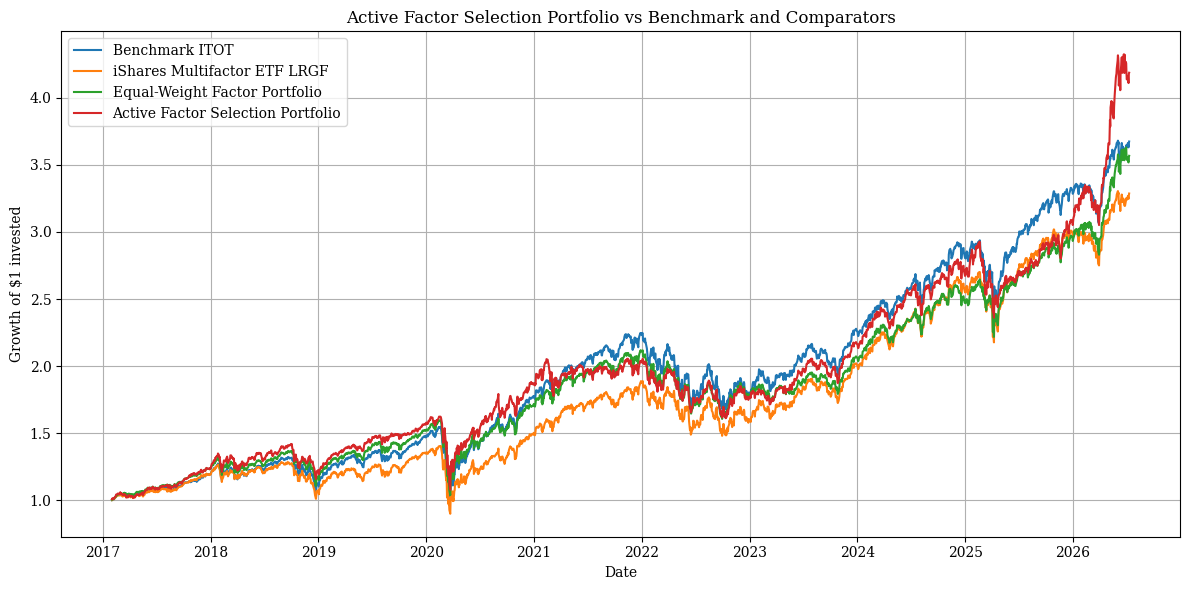

In [907]:
active_cumulative_performance = cumulative_returns(active_comparison_returns)

plt.figure(figsize=(12, 6))

for column in active_cumulative_performance.columns:
    plt.plot(
        active_cumulative_performance.index,
        active_cumulative_performance[column],
        label=column
    )

plt.title("Active Factor Selection Portfolio vs Benchmark and Comparators")
plt.xlabel("Date")
plt.ylabel("Growth of $1 invested")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

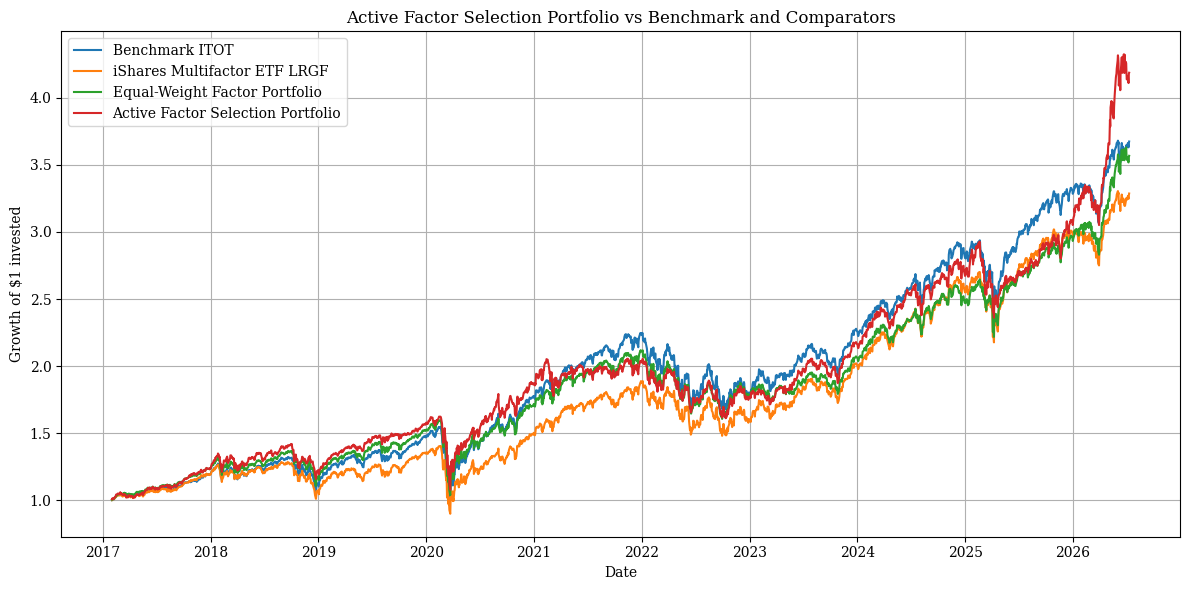

Chart saved to: outputs/15_active_factor_selection_comparison.png
File exists: True


In [908]:
active_comparison_chart_path = OUTPUT_DIR / "15_active_factor_selection_comparison.png"

active_cumulative_performance = cumulative_returns(active_comparison_returns)

plt.figure(figsize=(12, 6))

for column in active_cumulative_performance.columns:
    plt.plot(
        active_cumulative_performance.index,
        active_cumulative_performance[column],
        label=column
    )

plt.title("Active Factor Selection Portfolio vs Benchmark and Comparators")
plt.xlabel("Date")
plt.ylabel("Growth of $1 invested")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(active_comparison_chart_path, dpi=150)
plt.show()

print("Chart saved to:", active_comparison_chart_path)
print("File exists:", active_comparison_chart_path.exists())

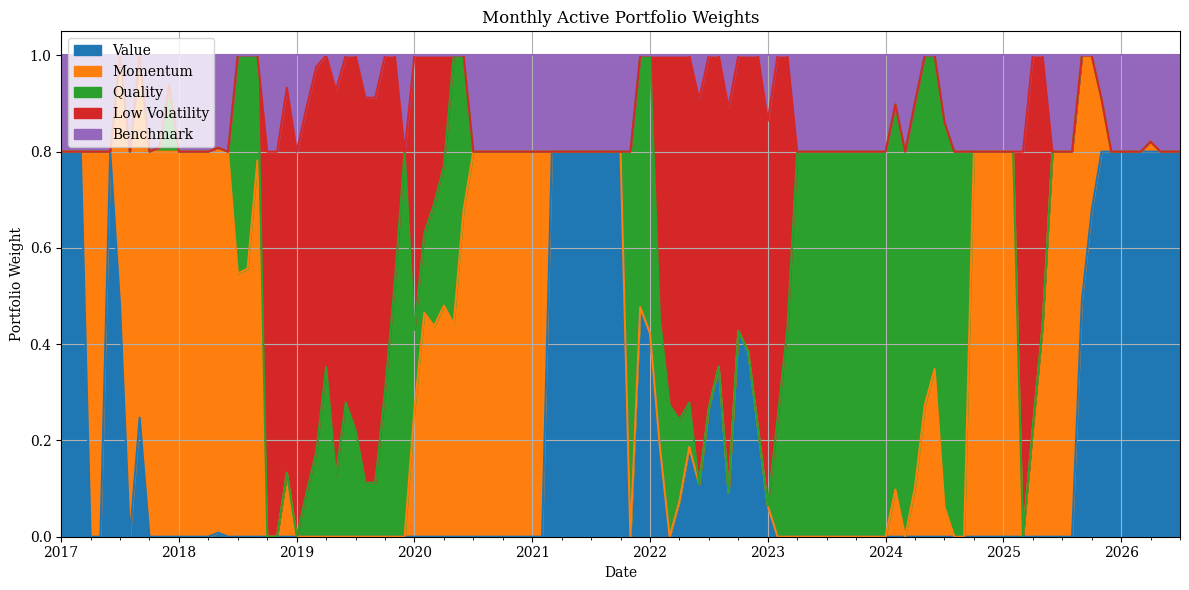

In [909]:
monthly_active_weights.plot.area(figsize=(12, 6))

plt.title("Monthly Active Portfolio Weights")
plt.xlabel("Date")
plt.ylabel("Portfolio Weight")
plt.legend(loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

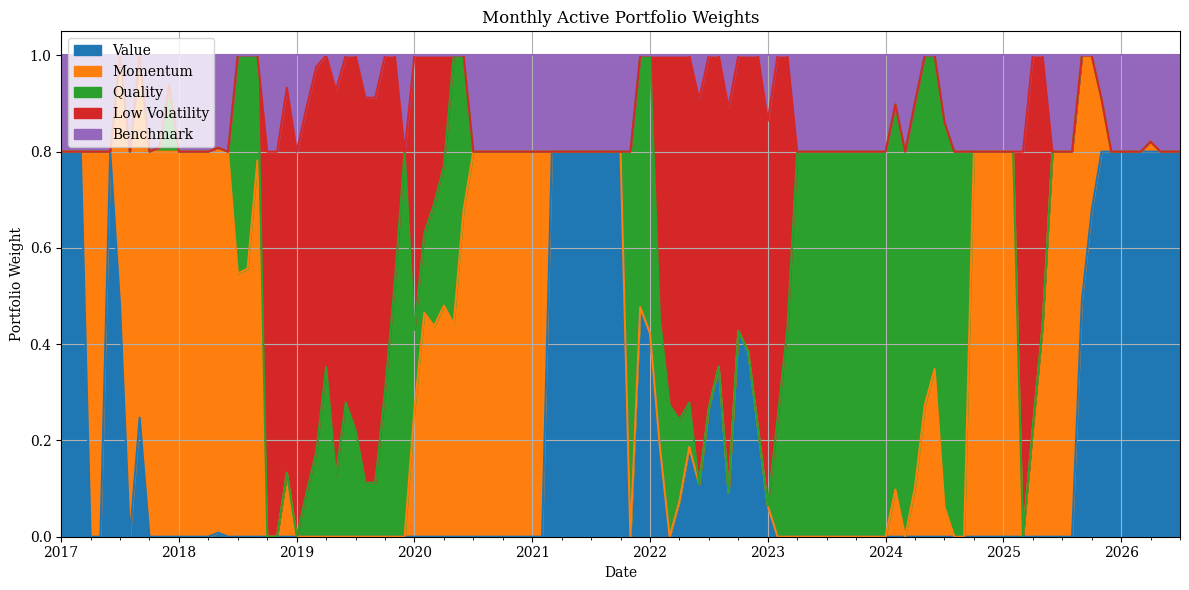

Chart saved to: outputs/16_monthly_active_weights.png
File exists: True


In [910]:
active_weights_chart_path = OUTPUT_DIR / "16_monthly_active_weights.png"

monthly_active_weights.plot.area(figsize=(12, 6))

plt.title("Monthly Active Portfolio Weights")
plt.xlabel("Date")
plt.ylabel("Portfolio Weight")
plt.legend(loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.savefig(active_weights_chart_path, dpi=150)
plt.show()

print("Chart saved to:", active_weights_chart_path)
print("File exists:", active_weights_chart_path.exists())

In [911]:
monthly_active_weights_path = OUTPUT_DIR / "17_monthly_active_weights.csv"
active_scores_path = OUTPUT_DIR / "18_active_scores.csv"

monthly_active_weights.to_csv(monthly_active_weights_path)
active_score.to_csv(active_scores_path)

print("Monthly active weights saved to:", monthly_active_weights_path)
print("File exists:", monthly_active_weights_path.exists())

print("Active scores saved to:", active_scores_path)
print("File exists:", active_scores_path.exists())

Monthly active weights saved to: outputs/17_monthly_active_weights.csv
File exists: True
Active scores saved to: outputs/18_active_scores.csv
File exists: True


The active factor selection portfolio applies a simple benchmark-relative allocation rule. It selects factor ETFs only when their active score and Information Ratio are positive. The allocation is based on risk-adjusted active characteristics rather than on raw past performance alone.

The strategy is rebalanced monthly and includes a benchmark fallback when no factor qualifies. This makes the framework more conservative and avoids forcing exposure to factors during periods when none of them display attractive benchmark-relative characteristics.

The purpose of this dynamic allocation is not to forecast markets, but to evaluate whether a transparent factor selection rule can provide a different risk-return profile compared with static factor allocation, a broad equity benchmark and an existing multifactor ETF.

## Final Interpretation and Report Preparation

This section interprets the final results of the project. The objective is to compare the Active Factor Selection Portfolio with three references:

- Benchmark ITOT
- iShares Multifactor ETF LRGF
- Equal-Weight Factor Portfolio

The interpretation focuses on risk-adjusted performance, downside risk, benchmark correlation and the practical limitations of dynamic factor allocation.

In [912]:
active_comparison_summary_formatted

,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown,Calmar Ratio,Correlation vs Benchmark
Benchmark ITOT,14.83%,18.65%,0.80,-35.00%,0.42,100.00%
iShares Multifactor ETF LRGF,13.48%,18.67%,0.72,-36.03%,0.37,98.31%
Equal-Weight Factor Portfolio,14.47%,17.68%,0.82,-34.98%,0.41,97.87%
Active Factor Selection Portfolio,16.44%,18.69%,0.88,-33.61%,0.49,92.43%


In [913]:
final_summary = active_comparison_summary.copy()

final_summary

,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown,Calmar Ratio,Correlation vs Benchmark
Benchmark ITOT,0.148299,0.186481,0.795246,-0.350039,0.423662,1.000000
iShares Multifactor ETF LRGF,0.134768,0.186678,0.721925,-0.360335,0.374007,0.983060
Equal-Weight Factor Portfolio,0.144706,0.176751,0.818702,-0.349814,0.413667,0.978715
Active Factor Selection Portfolio,0.164359,0.186901,0.879392,-0.336098,0.489021,0.924297


In [914]:
active_strategy_name = "Active Factor Selection Portfolio"

comparison_strategies = [
    "Benchmark ITOT",
    "iShares Multifactor ETF LRGF",
    "Equal-Weight Factor Portfolio"
]

active_vs_comparators = pd.DataFrame(index=comparison_strategies)

active_vs_comparators["Return Difference"] = (
    final_summary.loc[active_strategy_name, "Annualized Return"]
    - final_summary.loc[comparison_strategies, "Annualized Return"]
)

active_vs_comparators["Volatility Difference"] = (
    final_summary.loc[active_strategy_name, "Annualized Volatility"]
    - final_summary.loc[comparison_strategies, "Annualized Volatility"]
)

active_vs_comparators["Sharpe Difference"] = (
    final_summary.loc[active_strategy_name, "Sharpe Ratio"]
    - final_summary.loc[comparison_strategies, "Sharpe Ratio"]
)

active_vs_comparators["Drawdown Improvement"] = (
    final_summary.loc[active_strategy_name, "Maximum Drawdown"]
    - final_summary.loc[comparison_strategies, "Maximum Drawdown"]
)

active_vs_comparators

,Return Difference,Volatility Difference,Sharpe Difference,Drawdown Improvement
Benchmark ITOT,0.016060,0.000419,0.084146,0.013941
iShares Multifactor ETF LRGF,0.029591,0.000222,0.157467,0.024237
Equal-Weight Factor Portfolio,0.019653,0.010150,0.060691,0.013715


In [915]:
active_vs_comparators_path = OUTPUT_DIR / "19_active_vs_comparators.csv"

active_vs_comparators.to_csv(active_vs_comparators_path)

print("Active comparison table saved to:", active_vs_comparators_path)
print("File exists:", active_vs_comparators_path.exists())

Active comparison table saved to: outputs/19_active_vs_comparators.csv
File exists: True


In [916]:
best_annualized_return = final_summary["Annualized Return"].idxmax()
best_sharpe_ratio = final_summary["Sharpe Ratio"].idxmax()
best_calmar_ratio = final_summary["Calmar Ratio"].idxmax()
lowest_volatility = final_summary["Annualized Volatility"].idxmin()
lowest_drawdown = final_summary["Maximum Drawdown"].idxmax()

print("Best annualized return:", best_annualized_return)
print("Best Sharpe ratio:", best_sharpe_ratio)
print("Best Calmar ratio:", best_calmar_ratio)
print("Lowest volatility:", lowest_volatility)
print("Lowest maximum drawdown:", lowest_drawdown)

Best annualized return: Active Factor Selection Portfolio
Best Sharpe ratio: Active Factor Selection Portfolio
Best Calmar ratio: Active Factor Selection Portfolio
Lowest volatility: Equal-Weight Factor Portfolio
Lowest maximum drawdown: Active Factor Selection Portfolio


In [917]:
interpretation_summary = f"""
Final Results Summary

Best annualized return: {best_annualized_return}
Best Sharpe ratio: {best_sharpe_ratio}
Best Calmar ratio: {best_calmar_ratio}
Lowest volatility: {lowest_volatility}
Lowest maximum drawdown: {lowest_drawdown}
"""

print(interpretation_summary)


Final Results Summary

Best annualized return: Active Factor Selection Portfolio
Best Sharpe ratio: Active Factor Selection Portfolio
Best Calmar ratio: Active Factor Selection Portfolio
Lowest volatility: Equal-Weight Factor Portfolio
Lowest maximum drawdown: Active Factor Selection Portfolio



The final comparison evaluates whether the Active Factor Selection Portfolio improves the risk-return profile relative to the benchmark, the iShares multifactor ETF and the equal-weight factor portfolio.

The key interpretation depends on whether the active portfolio improves the Sharpe ratio, reduces drawdowns, lowers volatility or increases annualized returns. The objective is not necessarily to outperform on every metric, but to evaluate whether a transparent benchmark-relative allocation rule provides a more balanced risk-return profile.

If the active portfolio improves the Sharpe ratio or drawdown profile, the result suggests that dynamic factor selection may help manage factor exposure more effectively than a static equal-weight allocation. If the improvement is limited or inconsistent, the result still remains informative because it highlights the difficulty of factor timing and the importance of cautious interpretation.

The final results suggest that the Active Factor Selection Portfolio delivered the strongest overall performance over the sample period. It achieved an annualized return of 16.44%, compared with 14.83% for the benchmark, 13.48% for the iShares multifactor ETF and 14.47% for the equal-weight factor portfolio.

The improvement is not limited to returns. The active portfolio also generated the highest Sharpe ratio, at 0.88, and the highest Calmar ratio, at 0.49. Its maximum drawdown was -33.61%, compared with -35.00% for the benchmark and -36.03% for LRGF. This suggests that the benchmark-relative active factor selection rule improved risk-adjusted performance and downside risk over the period.

However, the results should be interpreted cautiously. The active portfolio had slightly higher volatility than the benchmark and higher volatility than the equal-weight factor portfolio. The model is also based on historical ETF performance and simplified assumptions. Therefore, the result should not be interpreted as evidence of a predictive trading strategy, but rather as an illustration of how ETF factor exposures can be monitored and allocated dynamically through a transparent portfolio analytics framework.

In [918]:
important_outputs = [
    "04_rolling_excess_returns.png",
    "14_final_performance_summary.csv",
    "15_active_factor_selection_comparison.png",
    "16_monthly_active_weights.png",
    "19_active_vs_comparators.csv"
]

for file_name in important_outputs:
    file_path = OUTPUT_DIR / file_name
    print(file_name, "exists:", file_path.exists())

04_rolling_excess_returns.png exists: True
14_final_performance_summary.csv exists: True
15_active_factor_selection_comparison.png exists: True
16_monthly_active_weights.png exists: True
19_active_vs_comparators.csv exists: True


## Conclusion

This project shows how ETFs can be used not only as passive market access instruments, but also as modular building blocks for factor-based portfolio analysis.

The analysis confirms that factor performance is time-varying. Value, Momentum, Quality and Low Volatility do not dominate consistently across the full sample period. This supports the use of rolling metrics and benchmark-relative analysis.

The Active Factor Selection Portfolio provides a transparent framework to monitor and allocate across factor exposures. However, the results must be interpreted cautiously. The model is based on historical ETF performance, uses simplified assumptions and does not account for all implementation costs, taxes or market frictions.

The project should therefore be understood as a portfolio analytics exercise rather than an investment recommendation or a predictive trading strategy.

## Monthly Automated Analytical Factsheet

This section generates a monthly analytical factsheet for the Active Factor Selection Portfolio.

The factsheet is generated as of the previous completed month-end. For example, if the notebook is run on 12 July, the factsheet is generated using data available up to the end of June.

The objective is to create an asset-management-style reporting output while keeping the project academic and analytical. The factsheet does not introduce uncalculated data. It only uses metrics, returns, allocation weights and charts produced by the Python notebook.

In [919]:
from pathlib import Path
from textwrap import fill

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.patches import Rectangle
from matplotlib.backends.backend_pdf import PdfPages

In [920]:
required_objects = [
    "active_comparison_returns",
    "monthly_active_weights",
    "active_cumulative_performance",
    "rolling_excess_returns",
    "performance_summary",
    "format_performance_table",
    "cumulative_returns",
    "OUTPUT_DIR"
]

missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise NameError(f"Missing required objects for the factsheet: {missing_objects}")

OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(exist_ok=True)

print("All required objects are available.")

All required objects are available.


In [921]:
# ============================================================
# Monthly reporting date logic
# ============================================================

# Leave as None to use today's date automatically.
# Example: if today is 12 July 2026, the reporting month will be June 2026.
FACTSHEET_GENERATION_DATE = None

# Manual override if needed.
# Example: MANUAL_FACTSHEET_REPORTING_DATE = "2026-06-30"
# Leave as None for automatic previous completed month-end logic.
MANUAL_FACTSHEET_REPORTING_DATE = None

if MANUAL_FACTSHEET_REPORTING_DATE is not None:
    generation_date = pd.Timestamp.today().normalize()
    factsheet_reporting_date = pd.to_datetime(MANUAL_FACTSHEET_REPORTING_DATE).normalize()

else:
    if FACTSHEET_GENERATION_DATE is None:
        generation_date = pd.Timestamp.today().normalize()
    else:
        generation_date = pd.to_datetime(FACTSHEET_GENERATION_DATE).normalize()

    factsheet_reporting_date = generation_date.replace(day=1) - pd.Timedelta(days=1)

available_dates = active_comparison_returns.index[
    active_comparison_returns.index <= factsheet_reporting_date
]

if len(available_dates) == 0:
    raise ValueError("No available data before the selected reporting date.")

factsheet_data_cutoff_date = available_dates.max()

factsheet_reporting_date_label = factsheet_reporting_date.strftime("%d/%m/%Y")
factsheet_data_cutoff_label = factsheet_data_cutoff_date.strftime("%d/%m/%Y")
factsheet_year_month = factsheet_reporting_date.strftime("%Y_%m")

print("Generation date:", generation_date.strftime("%d/%m/%Y"))
print("Reporting month-end:", factsheet_reporting_date_label)
print("Data cutoff used:", factsheet_data_cutoff_label)
print("Factsheet file period:", factsheet_year_month)

Generation date: 13/07/2026
Reporting month-end: 30/06/2026
Data cutoff used: 30/06/2026
Factsheet file period: 2026_06


In [922]:
# ============================================================
# Data as of reporting date
# ============================================================

active_comparison_returns_asof = active_comparison_returns.loc[
    :factsheet_data_cutoff_date
].copy()

if active_comparison_returns_asof.empty:
    raise ValueError("No return data available as of the selected reporting date.")

active_cumulative_performance_asof = cumulative_returns(
    active_comparison_returns_asof
)

monthly_active_weights_asof = monthly_active_weights.loc[
    monthly_active_weights.index <= factsheet_reporting_date
].copy()

if monthly_active_weights_asof.empty:
    raise ValueError("No monthly active weights available as of the selected reporting date.")

active_comparison_summary_asof = performance_summary(
    active_comparison_returns_asof,
    benchmark_series=active_comparison_returns_asof["Benchmark ITOT"]
)

active_comparison_summary_asof_formatted = format_performance_table(
    active_comparison_summary_asof
)

active_comparison_summary_asof_formatted

,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown,Calmar Ratio,Correlation vs Benchmark
Benchmark ITOT,14.78%,18.67%,0.79,-35.00%,0.42,100.00%
iShares Multifactor ETF LRGF,13.39%,18.69%,0.72,-36.03%,0.37,98.31%
Equal-Weight Factor Portfolio,14.73%,17.68%,0.83,-34.98%,0.42,97.92%
Active Factor Selection Portfolio,16.69%,18.69%,0.89,-33.61%,0.50,92.48%


In [923]:
# ============================================================
# Calculation and formatting helpers
# ============================================================

def format_percent(value):
    return f"{value:.2%}" if pd.notna(value) else ""

def format_number(value):
    return f"{value:.2f}" if pd.notna(value) else ""

def compound_period_return(return_series):
    return (1 + return_series.dropna()).prod() - 1

def period_returns_until_asof(return_data, as_of_date, start_date):
    """
    Computes compounded returns between start_date and as_of_date.
    The calculation uses only data available up to the reporting date.
    """
    start_date = pd.to_datetime(start_date)
    as_of_date = pd.to_datetime(as_of_date)

    period_data = return_data.loc[
        (return_data.index > start_date) &
        (return_data.index <= as_of_date)
    ]

    if period_data.empty:
        return pd.Series(np.nan, index=return_data.columns)

    return period_data.apply(compound_period_return)

In [924]:
# ============================================================
# Main performance table
# ============================================================

factsheet_strategy_name = "Active Factor Selection Portfolio"
factsheet_benchmark_name = "Benchmark ITOT"

sample_start = active_comparison_returns_asof.index.min().strftime("%d/%m/%Y")
sample_end = active_comparison_returns_asof.index.max().strftime("%d/%m/%Y")

short_names = {
    "Benchmark ITOT": "ITOT",
    "iShares Multifactor ETF LRGF": "LRGF",
    "Equal-Weight Factor Portfolio": "Equal-Weight",
    "Active Factor Selection Portfolio": "Active"
}

main_performance_table = active_comparison_summary_asof.rename(index=short_names).copy()

main_performance_table = main_performance_table.rename(columns={
    "Annualized Return": "Return",
    "Annualized Volatility": "Vol.",
    "Sharpe Ratio": "Sharpe",
    "Maximum Drawdown": "Max DD",
    "Calmar Ratio": "Calmar",
    "Correlation vs Benchmark": "Corr."
})

main_performance_table_display = main_performance_table.copy()

for col in ["Return", "Vol.", "Max DD", "Corr."]:
    main_performance_table_display[col] = main_performance_table_display[col].map(format_percent)

for col in ["Sharpe", "Calmar"]:
    main_performance_table_display[col] = main_performance_table_display[col].map(format_number)

main_performance_table_display

,Return,Vol.,Sharpe,Max DD,Calmar,Corr.
ITOT,14.78%,18.67%,0.79,-35.00%,0.42,100.00%
LRGF,13.39%,18.69%,0.72,-36.03%,0.37,98.31%
Equal-Weight,14.73%,17.68%,0.83,-34.98%,0.42,97.92%
Active,16.69%,18.69%,0.89,-33.61%,0.50,92.48%


In [925]:
# ============================================================
# Trailing performance table
# ============================================================

period_definitions = {
    "YTD": pd.Timestamp(year=factsheet_data_cutoff_date.year - 1, month=12, day=31),
    "1M": factsheet_data_cutoff_date - pd.DateOffset(months=1),
    "3M": factsheet_data_cutoff_date - pd.DateOffset(months=3),
    "1Y": factsheet_data_cutoff_date - pd.DateOffset(years=1),
    "3Y": factsheet_data_cutoff_date - pd.DateOffset(years=3),
}

trailing_performance = pd.DataFrame()

for period_name, start_date in period_definitions.items():
    trailing_performance[period_name] = period_returns_until_asof(
        active_comparison_returns_asof,
        factsheet_data_cutoff_date,
        start_date
    )

trailing_performance["Since Start"] = active_comparison_returns_asof.apply(
    compound_period_return
)

trailing_performance = trailing_performance.rename(index=short_names)

trailing_performance_display = trailing_performance.copy()

for col in trailing_performance_display.columns:
    trailing_performance_display[col] = trailing_performance_display[col].map(format_percent)

trailing_performance_display

,YTD,1M,3M,1Y,3Y,Since Start
ITOT,11.01%,-0.47%,19.08%,22.99%,74.53%,264.68%
LRGF,9.49%,-0.84%,18.24%,19.32%,76.46%,225.19%
Equal-Weight,23.78%,3.12%,28.28%,35.11%,90.99%,263.08%
Active,39.50%,0.91%,39.52%,57.23%,114.96%,325.76%


In [926]:
# ============================================================
# Active strategy versus comparators
# ============================================================

active_strategy_name = "Active Factor Selection Portfolio"

comparison_strategies = [
    "Benchmark ITOT",
    "iShares Multifactor ETF LRGF",
    "Equal-Weight Factor Portfolio"
]

active_vs_comparators_asof = pd.DataFrame(index=comparison_strategies)

active_vs_comparators_asof["Return Diff."] = (
    active_comparison_summary_asof.loc[active_strategy_name, "Annualized Return"]
    - active_comparison_summary_asof.loc[comparison_strategies, "Annualized Return"]
)

active_vs_comparators_asof["Vol. Diff."] = (
    active_comparison_summary_asof.loc[active_strategy_name, "Annualized Volatility"]
    - active_comparison_summary_asof.loc[comparison_strategies, "Annualized Volatility"]
)

active_vs_comparators_asof["Sharpe Diff."] = (
    active_comparison_summary_asof.loc[active_strategy_name, "Sharpe Ratio"]
    - active_comparison_summary_asof.loc[comparison_strategies, "Sharpe Ratio"]
)

active_vs_comparators_asof["DD Improvement"] = (
    active_comparison_summary_asof.loc[active_strategy_name, "Maximum Drawdown"]
    - active_comparison_summary_asof.loc[comparison_strategies, "Maximum Drawdown"]
)

active_vs_comparators_asof = active_vs_comparators_asof.rename(index=short_names)

active_vs_comparators_display = active_vs_comparators_asof.copy()

for col in ["Return Diff.", "Vol. Diff.", "DD Improvement"]:
    active_vs_comparators_display[col] = active_vs_comparators_display[col].map(format_percent)

active_vs_comparators_display["Sharpe Diff."] = active_vs_comparators_display["Sharpe Diff."].map(format_number)

active_vs_comparators_display

,Return Diff.,Vol. Diff.,Sharpe Diff.,DD Improvement
ITOT,1.91%,0.02%,0.10,1.39%
LRGF,3.30%,0.00%,0.18,2.42%
Equal-Weight,1.96%,1.01%,0.06,1.37%


In [927]:
# ============================================================
# Month-end model allocation
# ============================================================

latest_model_weights = monthly_active_weights_asof.iloc[-1].copy()
latest_model_weights = latest_model_weights[latest_model_weights > 0.0001]
latest_model_weights = latest_model_weights.sort_values(ascending=False)

latest_model_weights_display = latest_model_weights.map(lambda x: f"{x:.1%}")

latest_model_weights_display

,2026-06-30
Value,80.0%
Benchmark,20.0%


In [928]:
# ============================================================
# Factsheet display helpers — final robust wrapping version
# ============================================================

from matplotlib.patches import Rectangle
from matplotlib.backends.backend_pdf import PdfPages
from textwrap import fill
import matplotlib.dates as mdates
import numpy as np
import matplotlib as mpl
from matplotlib.font_manager import FontProperties
from matplotlib.textpath import TextPath

# ------------------------------------------------------------
# Font configuration
# ------------------------------------------------------------

mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman", "Times", "DejaVu Serif", "Liberation Serif"]
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

# ------------------------------------------------------------
# Visual identity
# ------------------------------------------------------------

DARK_GREEN = "#1F3D35"
COPPER = "#B87942"
CREAM = "#FAF7F0"
SAGE = "#E9EEE8"
STONE = "#C5C9C4"
CHARCOAL = "#2D3135"

line_colors = {
    "Benchmark ITOT": "#4D5557",
    "iShares Multifactor ETF LRGF": "#8A8F91",
    "Equal-Weight Factor Portfolio": "#5B8C82",
    "Active Factor Selection Portfolio": COPPER
}

factor_colors = {
    "Value": "#5B8C82",
    "Momentum": "#B87942",
    "Quality": "#7A9E7E",
    "Low Volatility": "#8A4F56",
    "Benchmark": "#D8D2C4"
}

# ------------------------------------------------------------
# Generic helpers
# ------------------------------------------------------------

def clean_axis(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

def apply_factsheet_font_axis(ax):
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily("serif")
    ax.title.set_fontfamily("serif")
    ax.xaxis.label.set_fontfamily("serif")
    ax.yaxis.label.set_fontfamily("serif")

def add_header(fig, subtitle, as_of_label):
    fig.add_artist(
        Rectangle(
            (0.02, 0.92),
            0.96,
            0.055,
            transform=fig.transFigure,
            facecolor=DARK_GREEN,
            edgecolor="none"
        )
    )

    fig.text(
        0.05, 0.948,
        "ETF FACTOR ROTATION PROJECT",
        fontsize=18,
        color="white",
        fontweight="bold",
        ha="left",
        va="center",
        family="serif"
    )

    fig.text(
        0.05, 0.928,
        subtitle,
        fontsize=10.5,
        color="white",
        ha="left",
        va="center",
        family="serif"
    )

    fig.text(
        0.93, 0.940,
        f"As of {as_of_label}",
        fontsize=11,
        color="white",
        fontweight="bold",
        ha="right",
        va="center",
        family="serif"
    )

def add_footer(fig):
    fig.add_artist(
        Rectangle(
            (0.04, 0.025),
            0.92,
            0.0015,
            transform=fig.transFigure,
            facecolor=DARK_GREEN,
            edgecolor="none"
        )
    )

    fig.text(
        0.5, 0.014,
        "Academic portfolio analytics document — not an investment recommendation",
        fontsize=7.5,
        ha="center",
        color=DARK_GREEN,
        family="serif"
    )

def add_panel_title(ax, title, fontsize=10.8):
    ax.text(
        0.00, 1.035,
        title,
        transform=ax.transAxes,
        fontsize=fontsize,
        fontweight="bold",
        color=DARK_GREEN,
        ha="left",
        va="bottom",
        family="serif"
    )

    ax.plot(
        [0, 1],
        [1.00, 1.00],
        transform=ax.transAxes,
        color=DARK_GREEN,
        linewidth=1.3,
        clip_on=False
    )

def draw_box_background(ax):
    ax.add_patch(
        Rectangle(
            (0, 0),
            1,
            1,
            transform=ax.transAxes,
            facecolor=CREAM,
            edgecolor=STONE,
            linewidth=1.0
        )
    )

# ------------------------------------------------------------
# Width-aware text wrapping
# ------------------------------------------------------------

def text_width_points(text, fontsize, weight="normal"):
    """
    Estimates rendered text width in points.
    This is more accurate than wrapping by character count.
    """
    prop = FontProperties(family="serif", size=fontsize, weight=weight)

    try:
        path = TextPath((0, 0), str(text), prop=prop)
        return path.get_extents().width
    except Exception:
        return len(str(text)) * fontsize * 0.45

def axes_width_points(ax):
    """
    Returns the width of an axis in points.
    """
    fig = ax.figure
    fig.canvas.draw()
    bbox = ax.get_window_extent()
    return bbox.width / fig.dpi * 72

def wrap_text_to_axis_width(ax, text, fontsize, max_width_fraction=0.88):
    """
    Wraps text using the real available width of the axis.
    """
    max_width = axes_width_points(ax) * max_width_fraction

    words = str(text).split()
    lines = []
    current_line = ""

    for word in words:
        candidate = word if current_line == "" else current_line + " " + word

        if text_width_points(candidate, fontsize) <= max_width:
            current_line = candidate
        else:
            if current_line:
                lines.append(current_line)
            current_line = word

    if current_line:
        lines.append(current_line)

    return lines if lines else [""]

def split_wrapped_text(text, wrap_width):
    return fill(str(text), wrap_width).split("\n")

# ------------------------------------------------------------
# Text boxes
# ------------------------------------------------------------

def draw_stacked_label_value_box(
    ax,
    title,
    items,
    value_wrap_width=46,
    max_fontsize=7.4,
    min_fontsize=4.9
):
    clean_axis(ax)
    draw_box_background(ax)
    add_panel_title(ax, title)

    prepared_items = []
    total_units = 0

    for label, value in items:
        value_lines = split_wrapped_text(value, value_wrap_width)
        prepared_items.append((label, value_lines))
        total_units += 1.05 + len(value_lines) + 0.70

    available_height = 0.80
    unit_step = available_height / max(total_units, 1)
    fontsize = max(min_fontsize, min(max_fontsize, unit_step * 128))

    y = 0.87

    for label, value_lines in prepared_items:
        ax.text(
            0.04,
            y,
            f"{label}:",
            transform=ax.transAxes,
            fontsize=fontsize,
            fontweight="bold",
            color=CHARCOAL,
            ha="left",
            va="top",
            family="serif"
        )

        y -= unit_step * 0.95

        for line in value_lines:
            ax.text(
                0.07,
                y,
                line,
                transform=ax.transAxes,
                fontsize=fontsize,
                color=CHARCOAL,
                ha="left",
                va="top",
                family="serif"
            )
            y -= unit_step

        y -= unit_step * 0.70

def draw_inline_label_value_box(
    ax,
    title,
    items,
    value_wrap_width=115,
    max_fontsize=7.2,
    min_fontsize=4.8,
    value_x=0.18
):
    clean_axis(ax)
    draw_box_background(ax)
    add_panel_title(ax, title)

    prepared_items = []
    total_units = 0

    for label, value in items:
        value_lines = split_wrapped_text(value, value_wrap_width)
        prepared_items.append((label, value_lines))
        total_units += max(1, len(value_lines)) + 0.85

    available_height = 0.80
    line_step = available_height / max(total_units, 1)
    fontsize = max(min_fontsize, min(max_fontsize, line_step * 135))

    y = 0.86

    for label, value_lines in prepared_items:
        ax.text(
            0.04,
            y,
            f"{label}:",
            transform=ax.transAxes,
            fontsize=fontsize,
            fontweight="bold",
            color=CHARCOAL,
            ha="left",
            va="top",
            family="serif"
        )

        ax.text(
            value_x,
            y,
            "\n".join(value_lines),
            transform=ax.transAxes,
            fontsize=fontsize,
            color=CHARCOAL,
            ha="left",
            va="top",
            family="serif"
        )

        y -= line_step * max(1, len(value_lines))
        y -= line_step * 0.85

def draw_paragraph_box(
    ax,
    title,
    paragraphs,
    max_fontsize=6.9,
    min_fontsize=4.8,
    max_width_fraction=0.88
):
    """
    Full-width paragraph box.
    The text is wrapped using rendered width, not a fixed character count.
    This fills more of the box while preventing right-side overflow.
    """
    clean_axis(ax)
    draw_box_background(ax)
    add_panel_title(ax, title)

    best_lines = None
    best_fontsize = min_fontsize

    for fontsize in np.arange(max_fontsize, min_fontsize - 0.05, -0.05):
        all_lines = []

        for paragraph in paragraphs:
            wrapped_lines = wrap_text_to_axis_width(
                ax,
                paragraph,
                fontsize=fontsize,
                max_width_fraction=max_width_fraction
            )
            all_lines.extend(wrapped_lines)
            all_lines.append("")

        if all_lines:
            all_lines = all_lines[:-1]

        available_height = 0.80
        line_step = available_height / max(len(all_lines), 1)

        if line_step >= 0.045:
            best_lines = all_lines
            best_fontsize = fontsize
            break

    if best_lines is None:
        best_lines = []

        for paragraph in paragraphs:
            wrapped_lines = wrap_text_to_axis_width(
                ax,
                paragraph,
                fontsize=min_fontsize,
                max_width_fraction=max_width_fraction
            )
            best_lines.extend(wrapped_lines)
            best_lines.append("")

        if best_lines:
            best_lines = best_lines[:-1]

        best_fontsize = min_fontsize

    available_height = 0.80
    line_step = available_height / max(len(best_lines), 1)

    y = 0.86

    for line in best_lines:
        if line.strip() == "":
            y -= line_step * 0.55
            continue

        ax.text(
            0.04,
            y,
            line,
            transform=ax.transAxes,
            fontsize=best_fontsize,
            color=CHARCOAL,
            ha="left",
            va="top",
            family="serif"
        )

        y -= line_step

def draw_table_panel(ax, df, title, fontsize=7.0, col_widths=None, index_name="Strategy", title_fontsize=10.6):
    clean_axis(ax)
    add_panel_title(ax, title, fontsize=title_fontsize)

    table_df = df.copy().reset_index()
    table_df.columns = [index_name] + list(table_df.columns[1:])

    table = ax.table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        cellLoc="center",
        loc="center",
        bbox=[0.00, 0.00, 1.00, 0.90],
        colWidths=col_widths
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor(STONE)
        cell.set_linewidth(0.55)

        if row == 0:
            cell.set_text_props(
                weight="bold",
                color=DARK_GREEN,
                fontfamily="serif"
            )
            cell.set_facecolor(SAGE)
        else:
            cell.set_text_props(
                color=CHARCOAL,
                fontfamily="serif"
            )
            cell.set_facecolor("white")

    return table

In [929]:
# ============================================================
# Factsheet text blocks and automated interpretation
# ============================================================

def format_signed_percent(value):
    if pd.isna(value):
        return ""
    sign = "+" if value >= 0 else ""
    return f"{sign}{value:.2%}"

def format_signed_number(value):
    if pd.isna(value):
        return ""
    sign = "+" if value >= 0 else ""
    return f"{sign}{value:.2f}"

# ------------------------------------------------------------
# Static text blocks
# ------------------------------------------------------------

key_data_items = [
    ("Reporting date", factsheet_reporting_date_label),
    ("Data cutoff", factsheet_data_cutoff_label),
    ("Comparable sample", f"{sample_start} to {sample_end}"),
    ("Frequency", "Daily ETF returns, monthly model rebalancing"),
    ("Document type", "Academic portfolio analytics factsheet")
]

objective_paragraphs = [
    "This factsheet summarizes a Python-based ETF factor rotation project.",
    "The project analyzes the cyclicality of Value, Momentum, Quality and Low Volatility ETF exposures.",
    "The active portfolio uses a transparent benchmark-relative allocation framework rather than a predictive trading model."
]

universe_items = [
    ("Factor ETFs", "VLUE for Value, MTUM for Momentum, QUAL for Quality and USMV for Low Volatility"),
    ("Benchmark", "ITOT"),
    ("Multifactor comparator", "LRGF")
]

methodology_items = [
    ("Active score", "benchmark-relative composite score based on Information Ratio, Sharpe advantage, volatility advantage and drawdown advantage"),
    ("Selection rule", "factors are selected only when their active characteristics are positive"),
    ("Weighting rule", "positive scores are normalized into weights, capped at 80% per factor, with residual allocation assigned to the benchmark")
]

limitations_paragraphs = [
    "This factsheet is not an investment recommendation, not a fund marketing document and not a trading signal.",
    "Results are historical and do not fully include transaction costs, taxes, bid-ask spreads or all implementation frictions.",
    "ETF proxies are imperfect representations of academic factors, and past performance does not indicate future results."
]

# ------------------------------------------------------------
# Automated interpretation
# ------------------------------------------------------------

active_name = "Active Factor Selection Portfolio"
benchmark_name = "Benchmark ITOT"

active_metrics = active_comparison_summary_asof.loc[active_name]
benchmark_metrics = active_comparison_summary_asof.loc[benchmark_name]

active_return = active_metrics["Annualized Return"]
benchmark_return = benchmark_metrics["Annualized Return"]

active_volatility = active_metrics["Annualized Volatility"]
benchmark_volatility = benchmark_metrics["Annualized Volatility"]

active_sharpe = active_metrics["Sharpe Ratio"]
benchmark_sharpe = benchmark_metrics["Sharpe Ratio"]

active_drawdown = active_metrics["Maximum Drawdown"]
benchmark_drawdown = benchmark_metrics["Maximum Drawdown"]

active_calmar = active_metrics["Calmar Ratio"]
benchmark_calmar = benchmark_metrics["Calmar Ratio"]

# Ranking logic
best_return_strategy = active_comparison_summary_asof["Annualized Return"].idxmax()
best_sharpe_strategy = active_comparison_summary_asof["Sharpe Ratio"].idxmax()
best_calmar_strategy = active_comparison_summary_asof["Calmar Ratio"].idxmax()
best_drawdown_strategy = active_comparison_summary_asof["Maximum Drawdown"].idxmax()

best_points = []

if best_return_strategy == active_name:
    best_points.append("annualized return")

if best_sharpe_strategy == active_name:
    best_points.append("Sharpe ratio")

if best_calmar_strategy == active_name:
    best_points.append("Calmar ratio")

if best_drawdown_strategy == active_name:
    best_points.append("maximum drawdown profile")

if best_points:
    if len(best_points) == 1:
        ranking_sentence = (
            f"The active portfolio ranked first on {best_points[0]} among the compared strategies."
        )
    else:
        ranking_sentence = (
            "The active portfolio ranked first on "
            + ", ".join(best_points[:-1])
            + " and "
            + best_points[-1]
            + " among the compared strategies."
        )
else:
    ranking_sentence = (
        "The active portfolio did not rank first on the main metrics, but remains useful as a transparent benchmark-relative allocation framework."
    )

# Relative comparison versus ITOT
if "ITOT" in active_vs_comparators_asof.index:
    benchmark_row = active_vs_comparators_asof.loc["ITOT"]
else:
    benchmark_row = active_vs_comparators_asof.iloc[0]

return_diff_vs_benchmark = benchmark_row["Return Diff."]
vol_diff_vs_benchmark = benchmark_row["Vol. Diff."]
sharpe_diff_vs_benchmark = benchmark_row["Sharpe Diff."]
drawdown_improvement_vs_benchmark = benchmark_row["DD Improvement"]

interpretation_paragraphs = [
    (
        f"Over the comparable sample, the active portfolio delivered {format_percent(active_return)} annualized return "
        f"versus {format_percent(benchmark_return)} for ITOT, with a Sharpe ratio of {format_number(active_sharpe)} "
        f"versus {format_number(benchmark_sharpe)}."
    ),
    (
        f"Versus ITOT, the return difference was {format_signed_percent(return_diff_vs_benchmark)}, "
        f"the Sharpe difference was {format_signed_number(sharpe_diff_vs_benchmark)}, "
        f"the volatility difference was {format_signed_percent(vol_diff_vs_benchmark)} and the maximum drawdown improvement was "
        f"{format_signed_percent(drawdown_improvement_vs_benchmark)}."
    ),
    (
        f"{ranking_sentence} These results should be read as historical portfolio analytics, not as evidence of predictive market timing."
    )
]

In [930]:
# ============================================================
# Generate the monthly factsheet — final polished version
# ============================================================

factsheet_pdf_path = OUTPUT_DIR / f"20_monthly_strategy_factsheet_{factsheet_year_month}.pdf"
factsheet_page1_path = OUTPUT_DIR / f"20_monthly_strategy_factsheet_{factsheet_year_month}_page1.png"
factsheet_page2_path = OUTPUT_DIR / f"20_monthly_strategy_factsheet_{factsheet_year_month}_page2.png"

performance_table_for_sheet = main_performance_table_display.copy()
performance_table_for_sheet = performance_table_for_sheet.rename(columns={
    "Return": "Ann. Return",
    "Vol.": "Ann. Vol."
})

active_comparison_for_sheet = active_vs_comparators_display.copy()
active_comparison_for_sheet = active_comparison_for_sheet.rename(columns={
    "DD Improvement": "DD Improv."
})

# ============================================================
# PAGE 1 — Performance Summary
# ============================================================

fig1 = plt.figure(figsize=(8.27, 11.69))
fig1.patch.set_facecolor("white")

add_header(
    fig1,
    "Monthly Analytical Factsheet — Performance Summary",
    factsheet_reporting_date_label
)

gs1 = fig1.add_gridspec(
    nrows=44,
    ncols=12,
    left=0.055,
    right=0.955,
    top=0.86,
    bottom=0.075,
    hspace=2.65,
    wspace=0.95
)

# Top boxes
ax_key = fig1.add_subplot(gs1[0:11, 0:4])
draw_stacked_label_value_box(
    ax_key,
    "Key Data",
    key_data_items,
    value_wrap_width=34,
    max_fontsize=7.1,
    min_fontsize=4.8
)

ax_obj = fig1.add_subplot(gs1[0:11, 4:8])
draw_paragraph_box(
    ax_obj,
    "Objective",
    objective_paragraphs,
    max_fontsize=7.2,
    min_fontsize=4.8,
    max_width_fraction=0.84
)

ax_univ = fig1.add_subplot(gs1[0:11, 8:12])
draw_stacked_label_value_box(
    ax_univ,
    "ETF Universe",
    universe_items,
    value_wrap_width=35,
    max_fontsize=7.1,
    min_fontsize=4.8
)

# Cumulative performance
ax_perf = fig1.add_subplot(gs1[12:20, 0:12])
add_panel_title(ax_perf, "Cumulative Performance")

for column in active_cumulative_performance_asof.columns:
    ax_perf.plot(
        active_cumulative_performance_asof.index,
        active_cumulative_performance_asof[column],
        label=column,
        linewidth=1.5,
        color=line_colors.get(column, None)
    )

ax_perf.set_ylabel("Growth of $1", fontsize=8)
ax_perf.grid(True, alpha=0.3)
ax_perf.tick_params(axis="both", labelsize=7)
ax_perf.xaxis.set_major_locator(mdates.YearLocator(1))
ax_perf.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
apply_factsheet_font_axis(ax_perf)

ax_perf.legend(
    fontsize=6.8,
    loc="upper left",
    ncol=2,
    prop={"family": "serif", "size": 6.8}
)

# Main performance metrics
ax_metrics = fig1.add_subplot(gs1[22:26, 0:12])
draw_table_panel(
    ax_metrics,
    performance_table_for_sheet,
    "Main Metrics — Annualized Over Comparable Sample",
    fontsize=6.8,
    col_widths=[0.16, 0.14, 0.14, 0.12, 0.14, 0.13, 0.13],
    index_name="Strategy",
    title_fontsize=10.4
)

# Trailing total returns
ax_trailing = fig1.add_subplot(gs1[27:31, 0:12])
draw_table_panel(
    ax_trailing,
    trailing_performance_display,
    "Trailing Total Returns",
    fontsize=7.0,
    col_widths=[0.16, 0.14, 0.14, 0.14, 0.14, 0.14, 0.16],
    index_name="Strategy"
)

# Automated interpretation note
ax_note = fig1.add_subplot(gs1[33:41, 0:12])
draw_paragraph_box(
    ax_note,
    "Automated Interpretation",
    interpretation_paragraphs,
    max_fontsize=6.9,
    min_fontsize=4.8,
    max_width_fraction=0.86
)

add_footer(fig1)

fig1.savefig(factsheet_page1_path, dpi=400)

# ============================================================
# PAGE 2 — Allocation and Methodology
# ============================================================

fig2 = plt.figure(figsize=(8.27, 11.69))
fig2.patch.set_facecolor("white")

add_header(
    fig2,
    "Monthly Analytical Factsheet — Allocation and Methodology",
    factsheet_reporting_date_label
)

gs2 = fig2.add_gridspec(
    nrows=52,
    ncols=12,
    left=0.075,
    right=0.955,
    top=0.86,
    bottom=0.075,
    hspace=3.10,
    wspace=1.15
)

# Monthly active weights
ax_weights = fig2.add_subplot(gs2[0:11, 0:12])
add_panel_title(ax_weights, "Monthly Active Weights")

weight_color_list = [
    factor_colors.get(col, None)
    for col in monthly_active_weights_asof.columns
]

monthly_active_weights_asof.plot.area(
    ax=ax_weights,
    color=weight_color_list
)

ax_weights.set_ylabel("Weight", fontsize=8)
ax_weights.set_xlabel("")
ax_weights.grid(True, alpha=0.3)
ax_weights.tick_params(axis="both", labelsize=7)
ax_weights.xaxis.set_major_locator(mdates.YearLocator(1))
ax_weights.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
apply_factsheet_font_axis(ax_weights)

ax_weights.legend(
    fontsize=6.8,
    loc="upper left",
    ncol=3,
    prop={"family": "serif", "size": 6.8}
)

# Month-end allocation with explanatory note
ax_alloc = fig2.add_subplot(gs2[15:20, 0:4])
clean_axis(ax_alloc)
add_panel_title(ax_alloc, "Month-End Allocation", fontsize=10.0)

allocation_table = pd.DataFrame({"Weight": latest_model_weights_display}).reset_index()
allocation_table.columns = ["Exposure", "Weight"]

table_alloc = ax_alloc.table(
    cellText=allocation_table.values,
    colLabels=allocation_table.columns,
    cellLoc="center",
    loc="center",
    bbox=[0.00, 0.30, 1.00, 0.60],
    colWidths=[0.60, 0.40]
)

table_alloc.auto_set_font_size(False)
table_alloc.set_fontsize(7.2)

for (row, col), cell in table_alloc.get_celld().items():
    cell.set_edgecolor(STONE)
    cell.set_linewidth(0.55)

    if row == 0:
        cell.set_text_props(
            weight="bold",
            color=DARK_GREEN,
            fontfamily="serif"
        )
        cell.set_facecolor(SAGE)
    else:
        cell.set_text_props(
            color=CHARCOAL,
            fontfamily="serif"
        )
        cell.set_facecolor("white")

ax_alloc.text(
    0.00,
    0.11,
    "Model allocation signal as of the reporting date.",
    transform=ax_alloc.transAxes,
    fontsize=5.8,
    color=CHARCOAL,
    ha="left",
    va="top",
    family="serif",
    style="italic"
)

# Strategy comparison
ax_active = fig2.add_subplot(gs2[15:20, 5:12])
draw_table_panel(
    ax_active,
    active_comparison_for_sheet,
    "Strategy vs Comparators",
    fontsize=6.8,
    col_widths=[0.23, 0.18, 0.18, 0.18, 0.23],
    index_name="Comparator",
    title_fontsize=10.0
)

# Methodology full width, inline format
ax_method = fig2.add_subplot(gs2[23:28, 0:12])
draw_inline_label_value_box(
    ax_method,
    "Methodology",
    methodology_items,
    value_wrap_width=105,
    max_fontsize=7.0,
    min_fontsize=4.8,
    value_x=0.22
)

# Factor cyclicality
ax_cycle = fig2.add_subplot(gs2[31:38, 0:12])
add_panel_title(ax_cycle, "Factor Cyclicality — Rolling Excess Returns vs Benchmark")

rolling_excess_returns_asof = rolling_excess_returns.loc[
    :factsheet_data_cutoff_date
].copy()

for column in rolling_excess_returns_asof.columns:
    ax_cycle.plot(
        rolling_excess_returns_asof.index,
        rolling_excess_returns_asof[column],
        label=column,
        linewidth=1.25,
        color=factor_colors.get(column, None)
    )

ax_cycle.axhline(0, linestyle="--", linewidth=0.8, color="#444444")
ax_cycle.set_ylabel("Excess Return", fontsize=8)
ax_cycle.grid(True, alpha=0.3)
ax_cycle.tick_params(axis="both", labelsize=7)
ax_cycle.xaxis.set_major_locator(mdates.YearLocator(1))
ax_cycle.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
apply_factsheet_font_axis(ax_cycle)

ax_cycle.legend(
    fontsize=6.8,
    loc="upper left",
    ncol=2,
    prop={"family": "serif", "size": 6.8}
)

# Limitations
ax_limits = fig2.add_subplot(gs2[42:50, 0:12])
draw_paragraph_box(
    ax_limits,
    "Important Notes and Limitations",
    limitations_paragraphs,
    max_fontsize=6.9,
    min_fontsize=4.8,
    max_width_fraction=0.86
)

add_footer(fig2)

fig2.savefig(factsheet_page2_path, dpi=400)

# ============================================================
# Save vector PDF directly
# ============================================================

with PdfPages(factsheet_pdf_path) as pdf:
    pdf.savefig(fig1)
    pdf.savefig(fig2)

plt.close(fig1)
plt.close(fig2)

print("Factsheet PDF saved to:", factsheet_pdf_path)
print("PDF exists:", factsheet_pdf_path.exists())

print("Page 1 PNG saved to:", factsheet_page1_path)
print("Page 1 exists:", factsheet_page1_path.exists())

print("Page 2 PNG saved to:", factsheet_page2_path)
print("Page 2 exists:", factsheet_page2_path.exists())

Factsheet PDF saved to: outputs/20_monthly_strategy_factsheet_2026_06.pdf
PDF exists: True
Page 1 PNG saved to: outputs/20_monthly_strategy_factsheet_2026_06_page1.png
Page 1 exists: True
Page 2 PNG saved to: outputs/20_monthly_strategy_factsheet_2026_06_page2.png
Page 2 exists: True


In [931]:
from google.colab import files

files.download(str(factsheet_pdf_path))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>